# Multi-Machine Operational-Space Database

The equilibrium branch of the multi-machine examples (#1620). Its question:

> Where do equilibria from different tokamaks sit on common operational and stability planes when only
> equilibrium-derived quantities are used?

The confinement and published-database branch is `multi_machine_confinement_database.ipynb`. The VEST reference
for the planes and their rendering is `conference_operational_space_atlas.ipynb`.

```text
public equilibrium -> vaft.omas.load -> ODS
    -> vaft.omas.equilibrium_state_table     (COCOS 11, one row per slice, quantity names and units)
    -> registered projections whose axes the table supplies   (vaft.diagram._op_space)
    -> vaft.plot.operational_space.operational_space_population (registered boundaries only)
```

**Display and export.** Figures are shown at the `screen` preset of `vaft.plot.presentation`, the size of an
inline page. Setting `VAFT_FIGURE_EXPORT_DIR` also writes every figure, at the `double_column` journal preset, as a
PDF there; the page itself never uses a print preset (#1815).

**Rules this page follows.**

- **Equilibrium only.** Every coordinate is read from, or derived from, the equilibrium ODS. No density, power,
  confinement time or kinetic profile is used. A projection that needs one is listed as unsupported and is not
  approximated.
- **Exact quantity identity.** A column is plotted on an axis only when it *is* that axis's quantity, by name
  and unit. $q_{95}$, $q_\psi$ at the edge, the cylinder's $q(a)$, $q_{cyl}$, $q_*$ and the estimated $q_{95}$
  are different quantities, and so are $l_i(3)$ and a cylinder's $l_i$. None stands in for another.
- **Boundaries come from `vaft.formula.boundaries`.** No coefficient is written here. Each legend entry states the
  boundary's basis (Empirical, Analytical, Numerical or Derived), and the table under each figure gives the
  machines it was calibrated on. A boundary calibrated on conventional tokamaks is not a limit for a spherical
  tokamak, so spherical and conventional populations are drawn on separate panels. The figure that holds every
  machine draws no boundary.
- **Nothing is dropped unseen.** A slice that cannot be read, or whose flux map fails Ampère's law, keeps its
  row and its reason. Each projection filters only the rows missing *its* two coordinates and prints its counts
  by machine.

## 1. Sources

These are the default sources of `multiple_tokamak_comparison.ipynb` (#458), and a test keeps the two notebooks
on the same URLs. They are plain variables, not a dataset registry, and they are fetched from upstream when the
notebook runs. Two attributes are stated per machine:

- **dataset type**: `experimental` (a measured discharge), `reference` (a scenario distributed with a modelling
  framework) or `design` (a device that has not operated). It sets the marker shape, and `design` is drawn open.
- **machine class**: `spherical_tokamak` or `conventional_tokamak`. This is a fact about the device, stated
  here and not inferred from a threshold. The aspect ratio each equilibrium actually has is printed beside it in
  Section 7.

In [ ]:
import importlib.util
import logging
import os
import re
import tempfile
import urllib.error
import urllib.request
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft
from vaft.diagram._op_space import get_projection, list_projections
from vaft.formula import boundaries as B
from vaft.omas import EQUILIBRIUM_STATE_UNITS, equilibrium_state_table
from vaft.plot.operational_space import operational_space_population, population_overlay
from vaft.plot.presentation import resolve_presentation

# Display and export are two presets (#1815). The page is read at screen size; a publication figure is written,
# at the double-column journal size, only when VAFT_FIGURE_EXPORT_DIR names a directory.
FORMAT, THEME = "screen", "technical"
EXPORT_FORMAT = "double_column"
EXPORT_DIR = Path(os.environ["VAFT_FIGURE_EXPORT_DIR"]) if os.environ.get("VAFT_FIGURE_EXPORT_DIR") else None
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
print("vaft", vaft.__version__, "| display format:", FORMAT, "| theme:", THEME, "| export:",
      f"{EXPORT_FORMAT} to {EXPORT_DIR}" if EXPORT_DIR else "off (set VAFT_FIGURE_EXPORT_DIR)")

vaft 0.7.1 | display format: screen | theme: technical | export: off (set VAFT_FIGURE_EXPORT_DIR)


In [ ]:
CACHE = Path(tempfile.gettempdir()) / "vaft-open-data"
CACHE.mkdir(parents=True, exist_ok=True)


class FetchError(RuntimeError):
    "The upstream URL could not be retrieved -- not a VAFT loader defect."


def fetch(url, *, timeout=120):
    "Download url into the temporary cache and return the local path."
    target = CACHE / url.rsplit("/", 1)[-1]
    if not target.exists():
        try:
            with urllib.request.urlopen(url, timeout=timeout) as response:
                payload = response.read()
        except (urllib.error.URLError, OSError, ValueError) as error:
            raise FetchError(f"{url}: {error}") from error
        target.write_bytes(payload)
    return target


FUSE = "https://raw.githubusercontent.com/ProjectTorreyPines/FUSE.jl/master/sample/"
vest_source = vaft.data.sample(39915, representation="imas")
d3d_url = FUSE + "D3D_eq_ods.json"
mastu_url = FUSE + "MASTU_Hmode.json"
jet_url = FUSE + "JET_99948_STATE0_eq.json"
tcv_url = ("https://raw.githubusercontent.com/SPCData/TCV-X21/main/"
           "1.experimental_data/reference_scenario/65402_t1.eqdsk")
sparc_url = ("https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/"
             "EQlibrary/sparc_1593.EQDSK_PsiOver2pi_negIp_negBt_negFpol")
iter_url = FUSE + "ITER_equilibrium_ods.json"

# machine, source, format, dataset type, machine class
SOURCES = (
    ("VEST", vest_source, "IMAS netCDF", "experimental", "spherical_tokamak"),
    ("DIII-D", d3d_url, "ODS JSON", "reference", "conventional_tokamak"),
    ("MAST-U", mastu_url, "ODS JSON", "reference", "spherical_tokamak"),
    ("JET", jet_url, "ODS JSON", "reference", "conventional_tokamak"),
    ("TCV", tcv_url, "GEQDSK", "experimental", "conventional_tokamak"),
    ("SPARC", sparc_url, "GEQDSK", "design", "conventional_tokamak"),
    ("ITER", iter_url, "ODS JSON", "design", "conventional_tokamak"),
)
MACHINES = [s[0] for s in SOURCES]
CLASS_OF = {s[0]: s[4] for s in SOURCES}
print("cache:", CACHE)

cache: <tmp>


## 2. Load and build the equilibrium-state table

`vaft.omas.equilibrium_state_table` reads every slice of every source. For each slice it identifies the COCOS
(an ambiguous identification takes the first candidate of the settled flux family and says so in
`cocos_status`), converts the slice to COCOS 11, and evaluates the quantities under the names of
`vaft.formula.boundaries`. It uses the derivation of the VEST atlas base table, so Section 9 can compare the two
exactly. Each slice is also checked against Ampère's law round its LCFS in the flux family it is read in. A
slice that fails gets `state_status = flux_conflict`: its $l_i$ and $\beta_p$ would be off by the mismatch, so it is
reported and is not a state.

Log messages raised while the table is built are counted and printed once each below, not hidden.

In [ ]:
class _Collect(logging.Handler):
    def __init__(self):
        super().__init__(logging.WARNING)
        self.messages = Counter()

    def emit(self, record):
        self.messages[f"{record.name}: {record.getMessage()}"] += 1


entries, load_status = [], {}
for machine, source, fmt, kind, machine_class in SOURCES:
    try:
        path = source if isinstance(source, Path) else fetch(source)
    except FetchError as error:
        load_status[machine] = f"fetch failed -- {error}"
        continue
    try:
        ods = vaft.omas.load(path)
    except Exception as error:  # a loader defect, not an upstream outage
        load_status[machine] = f"load failed -- {type(error).__name__}: {error}"
        continue
    # reading a missing OMAS path creates it, so ask before reading
    pulse = ods["dataset_description.data_entry.pulse"] if "dataset_description.data_entry.pulse" in ods else None
    pulse = int(pulse) if pulse not in (None, 0, "") else None   # pulse 0 is a placeholder, not a discharge
    entries.append((ods, {"machine": machine, "machine_class": machine_class, "dataset_type": kind,
                          "source_format": fmt, "dataset_source": path.name, "shot": pulse}))
    load_status[machine] = f"loaded from {fmt}"

collector = _Collect()
root = logging.getLogger()
root.addHandler(collector)
previous_level = root.level
root.setLevel(logging.WARNING)
try:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        STATES = equilibrium_state_table(entries)
finally:
    root.removeHandler(collector)
    root.setLevel(previous_level)

for machine in MACHINES:
    print(f"{machine:8s} {load_status[machine]}")
print()
for message, count in collector.messages.items():
    print(f"log x{count}: {message[:220]}")
for message, count in Counter(f"{w.category.__name__} from {Path(w.filename).name}:{w.lineno}: {w.message}"
                              for w in caught).items():
    print(f"warning x{count}: {message[:220]}")

19:09:58 INFO     Parsing data dictionary version 3.41.0 @dd_zip.py:89


<repo>/vaft/omas/__init__.py:213: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0
<repo>/vaft/omas/__init__.py:213: RuntimeWarning: Could not infer an IMAS DD version for geqdsk; using 3.41.0
<repo>/vaft/process/_equilibrium_parametric.py:375: RuntimeWarning: g-file BCENTR=-0.92864 T disagrees with FPOL[-1]/RCENTR=-0.932369 T (FPOL[-1]=-0.820485 T.m, RCENTR=0.88 m); using the FPOL value, which is the field the equilibrium was solved with (issue #325)


<repo>/vaft/database/_local.py:258: RuntimeWarning: g-file BCENTR=-0.92864 T disagrees with FPOL[-1]/RCENTR=-0.932369 T (FPOL[-1]=-0.820485 T.m, RCENTR=0.88 m); using the FPOL value, which is the field the equilibrium was solved with (issue #325)


VEST     loaded from IMAS netCDF
DIII-D   loaded from ODS JSON
MAST-U   loaded from ODS JSON
JET      loaded from ODS JSON
TCV      loaded from GEQDSK
SPARC    loaded from GEQDSK
ITER     loaded from ODS JSON

log x17: vaft.omas.update: equilibrium.vacuum_toroidal_field is inconsistent with tf: b0*r0 = 0.05985 T.m (b0 = 0.14962 T, r0 = 0.40000 m) against tf's 0.03175 T.m. Using tf.r0 = 0.4000 m for R_0.
log x1: vaft.omas.update: equilibrium.time_slice.8 has a degenerate psi range; skipping.
warning x3: RuntimeWarning from omas_physics.py:2855: invalid value encountered in scalar divide
warning x3: RuntimeWarning from omas_physics.py:2856: invalid value encountered in scalar divide


In [ ]:
status = STATES.groupby(["machine", "state_status"]).size().unstack(fill_value=0)
display(status.reindex([m for m in MACHINES if m in status.index]))
not_states = STATES[STATES["state_status"] != "valid"]
display(not_states[["machine", "time_index", "time_s", "state_status", "state_reason"]])
noted = STATES[STATES["state_notes"].fillna("").ne("")]
print(f"{len(noted)} state(s) with a quantity left missing, and why:")
display(noted[["machine", "time_index", "time_s", "state_status", "state_notes"]])

T = STATES[STATES["state_status"] == "valid"].copy()
# one category order for every figure, so a machine keeps its colour, and a dataset type its marker, throughout
T["machine"] = pd.Categorical(T["machine"], categories=MACHINES)
T["dataset_type"] = pd.Categorical(T["dataset_type"], categories=["experimental", "reference", "design"])
T["shot"] = T["shot"].astype("Int64")
T.attrs = dict(STATES.attrs)
print(f"{len(T)} states from {T['machine'].nunique()} machines; {len(not_states)} rows are not states")
display(T[["machine", "machine_class", "dataset_type", "source_format", "shot", "time_s", "time_index",
           "equilibrium_provenance", "cocos_source", "cocos_status", "cocos_target", "li_beta_source",
           "li_beta_crosscheck"]])

state_status  flux_conflict  valid
machine                           
VEST                      0      9
DIII-D                    0      1
MAST-U                    1      0
JET                       0      1
TCV                       0      1
SPARC                     0      1
ITER                      0      1

   machine  time_index  time_s   state_status                                       state_reason
10  MAST-U           0   0.006  flux_conflict  I_p and the psi map disagree: loop integral of...

1 state(s) with a quantity left missing, and why:


  machine  time_index  time_s state_status                                        state_notes
8    VEST           8   0.331        valid  li3_grid_integral: ValueError: `equilibrium.ti...

14 states from 6 machines; 1 rows are not states


   machine         machine_class  dataset_type source_format    shot  time_s  time_index                             equilibrium_provenance  cocos_source  \
0     VEST     spherical_tokamak  experimental   IMAS netCDF   39915   0.316           0  EFIT     02/26/2026    # 39915   331ms        ...            11   
1     VEST     spherical_tokamak  experimental   IMAS netCDF   39915   0.317           1  EFIT     02/26/2026    # 39915   331ms        ...            11   
2     VEST     spherical_tokamak  experimental   IMAS netCDF   39915   0.318           2  EFIT     02/26/2026    # 39915   331ms        ...            11   
3     VEST     spherical_tokamak  experimental   IMAS netCDF   39915   0.319           3  EFIT     02/26/2026    # 39915   331ms        ...            11   
4     VEST     spherical_tokamak  experimental   IMAS netCDF   39915   0.320           4  EFIT     02/26/2026    # 39915   331ms        ...            11   
5     VEST     spherical_tokamak  experimental   IMAS netC

**Rows that are not states, and missing quantities.** The VEST sample's last slice has no boundary outline. It
remains a row, but its shape, $q$ and $l_i$ columns are missing, and the notes table says why, so every projection
leaves it out.

The MAST-U slice fails Ampère's law: the loop ratio is 3.3, which matches neither flux family. The FUSE sample's
$I_p$ and $\psi$ map disagree, and the sample's own stored $l_i(3) = 12.6$ and $\beta_p = 12.6$ show the same
inconsistency. The row keeps its values for inspection and is not plotted.

The same check is what found the TCV-X21 g-file read 2$\pi$ off: it stores $\psi$ in weber (COCOS 17), and the
GEQDSK reader used to multiply it by $2\pi$ again, giving $l_i(3) \approx 33$. The reader now takes the file's flux
family from its data (#294, #1684), and TCV enters as a state with $l_i(3) = 0.83$.

MAST-U was the second spherical tokamak in
the set, so the spherical population here is VEST alone.

**The VEST log message** (`b0*r0` inconsistent with `tf`) is the reference-radius check of #325. On this sample,
`b0` at $r_0$ = 0.4 m agrees with the boundary $F/R$, while the packaged `tf` IDS field does not. The check
therefore keeps $R_0$ = 0.4 m, as the atlas does, and the message changes no value.

## 3. Feature availability by machine

Units are those of `table.attrs["units"]`, which the renderer checks against each axis. Missing values stay
missing. A machine whose only slice is not a state (MAST-U) shows zero here because they were excluded in
Section 2, not because a quantity is absent.

Two toroidal fields appear, as in the VEST atlas. `toroidal_field` (the $I_p$–$B_T$ axis) and the shape coordinates
$q_*$, $q^*$ and the $q_{95}$ estimates use the vacuum field at the geometric radius, $B_0 R_0/R_{geo}$.
`normalized_current` $I_N$ and $\beta_N$ use $B_0$ at the reference radius $R_0$, the IMAS DD convention. On VEST the
two differ by about 18 %, so $I_p/(a\,B_T)$ computed from the `toroidal_field` column is not the $I_N$ column.

In [ ]:
units = pd.Series(T.attrs["units"], name="unit")
available = T.groupby("machine", observed=False)[list(EQUILIBRIUM_STATE_UNITS)].count().T
available.insert(0, "unit", units)
display(available)

machine                                       unit  VEST  DIII-D  MAST-U  JET  TCV  SPARC  ITER
plasma_current                                  MA     9       1       0    1    1      1     1
toroidal_field                                   T     8       1       0    1    1      1     1
b0                                               T     9       1       0    1    1      1     1
reference_major_radius                           m     9       1       0    1    1      1     1
major_radius                                     m     8       1       0    1    1      1     1
minor_radius                                     m     8       1       0    1    1      1     1
aspect_ratio                                     -     8       1       0    1    1      1     1
inverse_aspect_ratio                             -     8       1       0    1    1      1     1
elongation                                       -     8       1       0    1    1      1     1
area_elongation                         

## 4. Which registered projections the equilibrium supplies

The projections are discovered, not listed by hand: every key of `list_projections()` is tested. A projection is
supported when both of its axis quantities are columns of the state table in the axis unit. This is the
intersection of the registered requirements with the available quantities. A boundary input that is not on an
axis, such as the shape of a current limit, is taken from the population plotted (the renderer's documented median)
and printed under each figure.

In [ ]:
coverage, unsupported = [], []
for key in list_projections():
    p = get_projection(key)
    reasons = []
    for q in (p.x, p.y):
        if q.name not in T.attrs["units"]:
            reasons.append(f"{q.name} is not an equilibrium-state column ({q.definition})")
        elif T.attrs["units"][q.name] != q.unit:
            reasons.append(f"{q.name} is in {T.attrs['units'][q.name]}, the axis in {q.unit}")
    if reasons:
        unsupported.append({"projection": key, "title": p.title, "reason": "; ".join(reasons)})
        continue
    both = T[p.x.name].notna() & T[p.y.name].notna()
    row = {"projection": key, "x": p.x.name, "y": p.y.name, "states": int(both.sum()), "excluded": int((~both).sum())}
    row.update({m: int(both[T["machine"] == m].sum()) for m in MACHINES})
    coverage.append(row)
SUPPORTED = [r["projection"] for r in coverage]
print(f"{len(SUPPORTED)} of {len(list_projections())} registered projections are supported by the equilibrium alone")
display(pd.DataFrame(coverage).set_index("projection"))

10 of 18 registered projections are supported by the equilibrium alone


                                             x                                     y  states  excluded  VEST  DIII-D  MAST-U  JET  TCV  SPARC  ITER
projection                                                                                                                                         
beta_n_li              internal_inductance_li3                       normalized_beta      13         1     8       1       0    1    1      1     1
ip_bt                           toroidal_field                        plasma_current      13         1     8       1       0    1    1      1     1
ip_kappa                            elongation                        plasma_current      13         1     8       1       0    1    1      1     1
li_qa_wesson                edge_safety_factor               internal_inductance_li3      13         1     8       1       0    1    1      1     1
q95_estimate_in             normalized_current   edge_safety_factor_95_estimate_iter      13         1     8    

**Unsupported projections.** These need a quantity that is not an equilibrium property, or that a toroidal
equilibrium does not define. The Hugill planes (conventional and spherical-tokamak), the Greenwald-fraction and L–H planes need the
line-averaged density and the loss power, and the ρ* planes need the plasma temperature, density or energy confinement time. They belong to a later notebook that supplies them. The Cheng–Furth–Boozer plane is drawn on a
straight cylinder's $q(a)$ and $l_i$, the model's own coordinates. Placing a toroidal equilibrium on it needs a
documented mapping, which belongs to the $l_i$–$q$ family work (#1422, #1603), not a substitution made here.

In [ ]:
display(pd.DataFrame(unsupported).set_index("projection"))

                                                                      title                                             reason
projection                                                                                                                    
greenwald_fraction_power              Greenwald fraction against loss power  loss_power is not an equilibrium-state column ...
hugill                                                       Hugill diagram  murakami_parameter is not an equilibrium-state...
hugill_st                                  Spherical-tokamak Hugill diagram  murakami_parameter is not an equilibrium-state...
lh_threshold              Loss power against line-averaged density (L-H ...  line_average_density is not an equilibrium-sta...
li_qa_cheng                   Cheng-Furth-Boozer MHD-stable l_i-q(a) domain  cylinder_edge_safety_factor is not an equilibr...
rho_star_beta_n               Normalised beta against normalised gyroradius  rho_star_verdoolaege_2021 is not a

## 5. Representative states

The full population is always drawn. Representative states are added on top of it by a fixed rule: **every
source with at least two valid slices is also drawn as one time trajectory**, with its slices in time order and
an arrow on the last step. No other selection is made.

In [ ]:
TIME = "time_s"
multi = T.groupby(["machine", "dataset_source"], observed=True).size()
TRAJECTORIES = {}
for (machine, source), n in multi[multi >= 2].items():
    sub = T[(T["machine"] == machine) & (T["dataset_source"] == source)]
    label = f"{machine} {source} ({n} slices, {1e3 * sub[TIME].min():.0f}-{1e3 * sub[TIME].max():.0f} ms)"
    TRAJECTORIES[label] = sub
print("representative states (rule: every source with >= 2 valid slices):", list(TRAJECTORIES) or "none")

representative states (rule: every source with >= 2 valid slices): ['VEST imas.nc (9 slices, 316-331 ms)']


## 6. Every supported projection, every machine

Each projection starts with **all machines** on one figure. Colour is the machine and marker shape the dataset
type (design open), and representative trajectories are drawn on top. **No boundary is drawn on it**, because the
population mixes machine classes and no registered boundary is stated for all of them.

The registered boundaries are then drawn on populations that one boundary can describe:

- **By machine class** (conventional tokamaks, then spherical tokamaks) when every default boundary of the
  projection depends only on the axes.
- **One machine at a time** when a default boundary needs an input that is not on an axis, such as the shape
  $a$, $R_0$, $\kappa$, $\delta$ of a current limit or the $\kappa$ of Freidberg's $(1+\kappa)/2$. Each machine's
  panel draws the limit at that machine's own median shape, the renderer's documented aggregation over the panel's
  states. A median taken over machines of different sizes would be the shape of none of them.

Every boundary panel declares its population's class in `table.attrs["machine_class"]`. The renderer reads it
(#1628, #1664) and marks each boundary in the legend and in `ax.vaft_applicability`: OUTSIDE when a plotted value
leaves the boundary's declared range or its declared machine class excludes the population, SUPPORTED only when the
class covers the population *and* a declared range was tested on the plotted values, and UNASSESSED otherwise. The
status column below copies that verdict; this page makes none of its own. Each panel carries a footnote, on the figure, with the machines each drawn boundary was
calibrated on. The table under each panel lists, for every requested boundary, its basis and origin, those machines,
the fixed inputs it was drawn at, and why it was left off if it was. A boundary calibrated on conventional tokamaks is still drawn on a spherical-tokamak panel,
so the two can be compared. It is **not** a limit for those points, and the reverse holds for a boundary calibrated
on spherical tokamaks.

In [ ]:
SPANS = {"troyon": dict(x_range=(0.0, None), y_range=(0.0, None)),
         "qstar_in": dict(y_range=(0.0, None)),
         "ip_kappa": dict(x_range=(1.0, None), y_range=(0.0, None)),
         "ip_bt": dict(x_range=(0.0, None), y_range=(0.0, None))}
CLASSES = (("conventional_tokamak", "Conventional tokamaks"), ("spherical_tokamak", "Spherical tokamaks"))
MARKER_SIZE = 90   # a dozen states, not a campaign: markers large enough to read
FIGURES = {}


def _status(ax, key):
    # the renderer's applicability verdict when it gives one (#1628); this page never makes one itself
    found = getattr(ax, "vaft_applicability", None)
    if not found or key not in found:
        return "not reported by this renderer"
    value = found[key]
    return value[0] if isinstance(value, (tuple, list)) else str(value)


def boundary_table(ax, population):
    plan = ax.vaft_overlay
    rows = []
    for curve in plan.curves:
        entry = B.get_boundary(curve.key)
        rows.append({"boundary": curve.key, "drawn": True, "basis": entry.basis, "origin": entry.origin,
                     "calibrated on (registry)": entry.applicability.machine_class or "not stated",
                     "fixed inputs": ", ".join(f"{k}={v:.3g}" for k, v in curve.fixed.items()) or "-",
                     f"applicability for {population}": _status(ax, curve.key)})
    for key, reason in plan.omitted:
        entry = B.get_boundary(key)
        rows.append({"boundary": key, "drawn": False, "basis": getattr(entry, "basis", ""),
                     "origin": getattr(entry, "origin", ""),
                     "calibrated on (registry)": getattr(getattr(entry, "applicability", None), "machine_class", ""),
                     "fixed inputs": f"left off: {reason}", f"applicability for {population}": _status(ax, key)})
    return pd.DataFrame(rows).set_index("boundary") if rows else None


def _render(table, key, title, fmt, calibration, marker, **kw):
    fig, ax = operational_space_population(table, key, color="machine", marker=marker, hollow=["design"],
                                           legend_keys=False, boundary_style="inline", time_column=TIME,
                                           title=title, format=fmt, theme=THEME, marker_size=MARKER_SIZE,
                                           **SPANS.get(key, {}), **kw)
    if calibration and ax.vaft_overlay.curves:
        # on the figure itself, so an exported panel keeps it: what each line was calibrated on (registry text),
        # at the legend size of the format the figure was drawn in
        calibrated = "; ".join(f"{c.key}: {B.get_boundary(c.key).applicability.machine_class or 'not stated'}"
                               for c in ax.vaft_overlay.curves)
        fig.text(0.01, 0.0, "Boundaries are drawn as registered and are not limits outside their calibration. "
                 f"Calibrated on: {calibrated}.", wrap=True, ha="left", va="top",
                 fontsize=resolve_presentation(fmt, THEME).rc()["legend.fontsize"])
    return fig, ax


def draw(table, key, title, notes, calibration=False, marker="dataset_type", **kw):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fig, ax = _render(table, key, title, FORMAT, calibration, marker, **kw)
        plt.show()
        if EXPORT_DIR is not None:   # the same figure at publication size, written and not shown
            out, _ = _render(table, key, title, EXPORT_FORMAT, calibration, marker, **kw)
            EXPORT_DIR.mkdir(parents=True, exist_ok=True)
            out.savefig(EXPORT_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", f"{key} {title}").strip("_") + ".pdf"),
                        bbox_inches="tight")
            plt.close(out)
    notes += [str(w.message) for w in caught]
    return fig, ax


def section(key):
    p = get_projection(key)
    both = T[p.x.name].notna() & T[p.y.name].notna()
    counts = pd.DataFrame({"included": T[both].groupby("machine", observed=False).size(),
                           "excluded": T[~both].groupby("machine", observed=False).size()})
    missing = {m: sorted({q for q in (p.x.name, p.y.name) if T.loc[(T["machine"] == m) & ~both, q].isna().any()})
               for m in MACHINES}
    counts["missing quantity"] = [", ".join(missing[m]) or "-" for m in counts.index]
    print(f"{p.title} ({key}): x = {p.x.name} [{p.x.unit}], y = {p.y.name} [{p.y.unit}]")
    display(counts.T)
    notes = []
    data = T[both]
    data.attrs = dict(T.attrs)
    trajectories = {label: sub[sub[p.x.name].notna() & sub[p.y.name].notna()] for label, sub in TRAJECTORIES.items()}
    draw(data, key, f"{p.title}: all machines (no boundary)", notes, boundaries=False,
         trajectories={k: v for k, v in trajectories.items() if len(v) >= 2} or None)
    FIGURES[key] = int(both.sum())
    off_axis = sorted({name for b in p.default_boundaries for name in getattr(B.get_boundary(b), "input_names", ())
                       if name not in (p.x.name, p.y.name)})
    if off_axis:
        print(f"boundaries need {off_axis} off the axes: one panel per machine, at its own median")
        panels = [(data[data["machine"] == m], f"{m} at its own shape", CLASS_OF[m]) for m in MACHINES]
    else:
        panels = [(data[data["machine_class"] == c], label.lower(), c) for c, label in CLASSES]
    for sub, label, machine_class in panels:
        if sub.empty:
            print(f"{label}: no state has both coordinates")
            continue
        sub = sub.copy()
        sub.attrs = dict(T.attrs, machine_class=machine_class)
        _, ax = draw(sub, key, f"{p.title}: {label}", notes, calibration=True, boundaries="default")
        report = boundary_table(ax, machine_class.replace("_", " "))
        if report is not None:
            display(report)
    for message in dict.fromkeys(notes):   # each extrapolation or omission note once per projection
        print("note:", message)

### Troyon: $\beta_T$ against $I_N$

The Troyon limit $\beta_N^{max}$ is the ratio of the axes, so it is a line through the origin.

Troyon beta limit (troyon): x = normalized_current [MA m^-1 T^-1], y = toroidal_beta [%]


machine                                        VEST DIII-D MAST-U JET TCV SPARC ITER
included                                          8      1      0   1   1     1    1
excluded                                          1      0      0   0   0     0    0
missing quantity  normalized_current, toroidal_beta      -      -   -   -     -    -

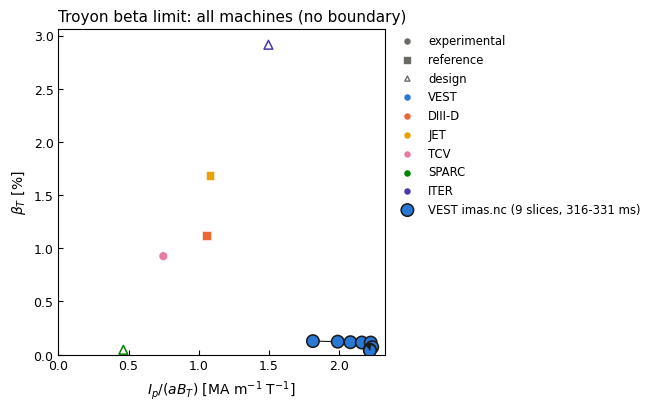

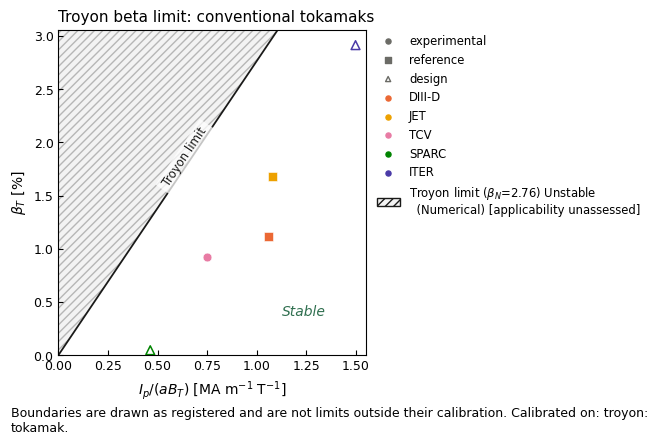

          drawn                basis     origin calibrated on (registry)          fixed inputs applicability for conventional tokamak
boundary                                                                                                                             
troyon     True  ideal_mhd_numerical  published                  tokamak  normalized_beta=2.76                             UNASSESSED

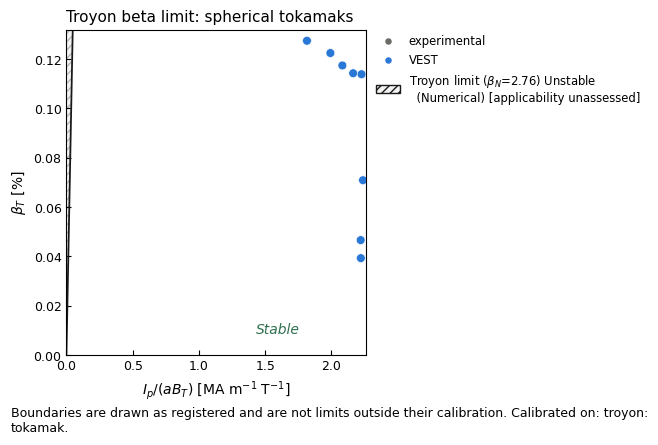

          drawn                basis     origin calibrated on (registry)          fixed inputs applicability for spherical tokamak
boundary                                                                                                                          
troyon     True  ideal_mhd_numerical  published                  tokamak  normalized_beta=2.76                          UNASSESSED

In [ ]:
if "troyon" in SUPPORTED:
    section("troyon")
else:
    print("troyon is not supported by this table")

### $\beta_N$ against $l_i(3)$

The same Troyon limit drawn as a horizontal line. An $l_i$-scaled limit is not registered, so it is not drawn.

Normalized beta against internal inductance (beta_n_li): x = internal_inductance_li3 [-], y = normalized_beta [% m T/MA]


machine                                               VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                 8      1      0   1   1     1    1
excluded                                                 1      0      0   0   0     0    0
missing quantity  internal_inductance_li3, normalized_beta      -      -   -   -     -    -

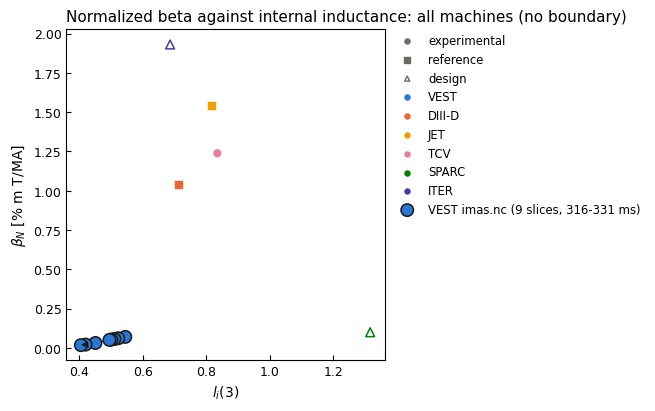

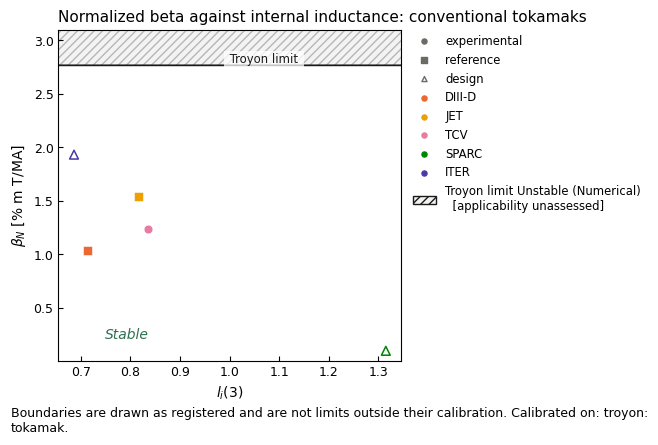

          drawn                basis     origin calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                    
troyon     True  ideal_mhd_numerical  published                  tokamak            -                             UNASSESSED

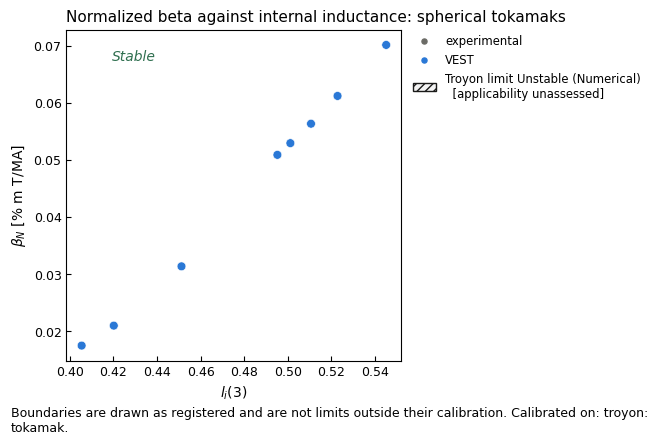

          drawn                basis     origin calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                 
troyon     True  ideal_mhd_numerical  published                  tokamak            -                          UNASSESSED

note: boundary 'troyon' at y = 2.76 lies outside the plotted range 0.0148..0.0728 and is not in view


In [ ]:
if "beta_n_li" in SUPPORTED:
    section("beta_n_li")
else:
    print("beta_n_li is not supported by this table")

### $l_i(3)$ against $q_{95}$

The only registered limit on $q_{95}$ is the ITER design guideline. The $l_i$–$q$ literature boundaries use $q_\psi$ or a cylinder's $q(a)$, so they are not drawn here.

Internal inductance against q95 (q95_li): x = edge_safety_factor_95 [-], y = internal_inductance_li3 [-]


machine                                                     VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                       8      1      0   1   1     1    1
excluded                                                       1      0      0   0   0     0    0
missing quantity  edge_safety_factor_95, internal_inductance_li3      -      -   -   -     -    -

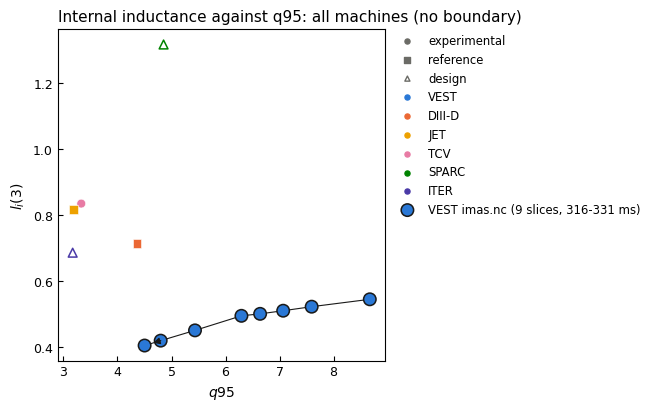

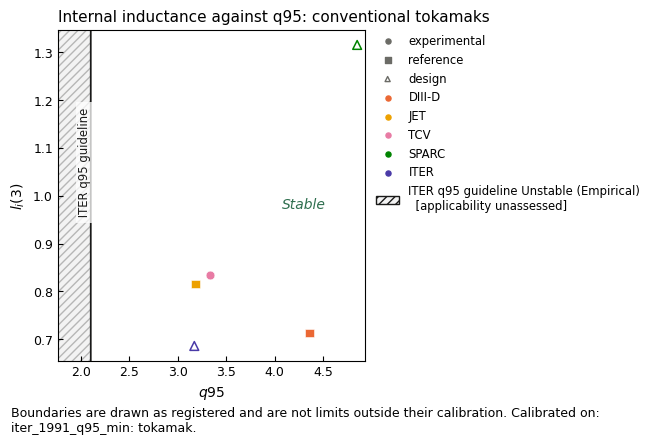

                   drawn      basis     origin calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                   
iter_1991_q95_min   True  empirical  published                  tokamak            -                             UNASSESSED

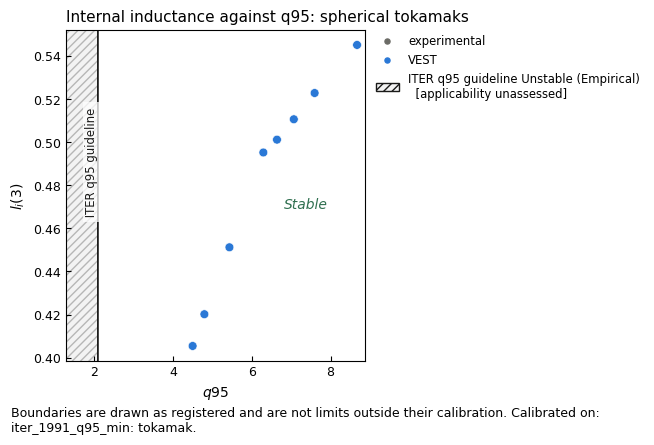

                   drawn      basis     origin calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                
iter_1991_q95_min   True  empirical  published                  tokamak            -                          UNASSESSED

In [ ]:
if "q95_li" in SUPPORTED:
    section("q95_li")
else:
    print("q95_li is not supported by this table")

### $l_i(3)$ against edge $q_\psi$ (Wesson, JET)

The JET operating-space boundaries of Wesson et al. (1989) and the $q_\psi = 2$ low-$q$ limit. A reference ends where its source ends; the population is never cut to it. #1603 refines this family, and this page picks the refinement up through the registry. The x axis is $q$ at the last profile point ($\psi_N = 1$). For a diverted equilibrium (DIII-D, JET, SPARC, ITER here) that value depends on where the source's profile stops short of the separatrix. Wesson's JET data were largely limiter plasmas, so read the conventional panel with that in mind.

JET empirical l_i-q_psi operating space (li_qa_wesson): x = edge_safety_factor [-], y = internal_inductance_li3 [-]


machine                                                  VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                    8      1      0   1   1     1    1
excluded                                                    1      0      0   0   0     0    0
missing quantity  edge_safety_factor, internal_inductance_li3      -      -   -   -     -    -

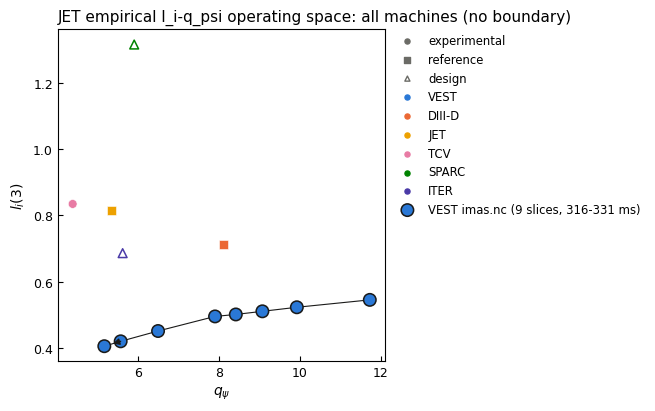

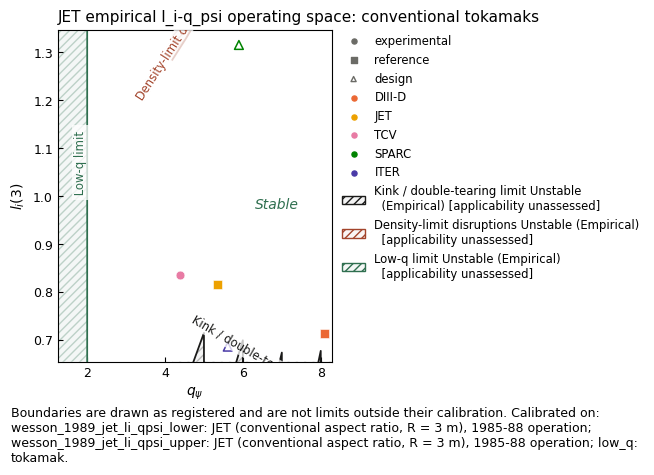

                               drawn      basis      origin                           calibrated on (registry) fixed inputs  \
boundary                                                                                                                      
wesson_1989_jet_li_qpsi_lower   True  empirical  reproduced  JET (conventional aspect ratio, R = 3 m), 1985...            -   
wesson_1989_jet_li_qpsi_upper   True  empirical  reproduced  JET (conventional aspect ratio, R = 3 m), 1985...            -   
low_q                           True  empirical   published                                            tokamak            -   

                              applicability for conventional tokamak  
boundary                                                              
wesson_1989_jet_li_qpsi_lower                             UNASSESSED  
wesson_1989_jet_li_qpsi_upper                             UNASSESSED  
low_q                                                     UNASSESSED  

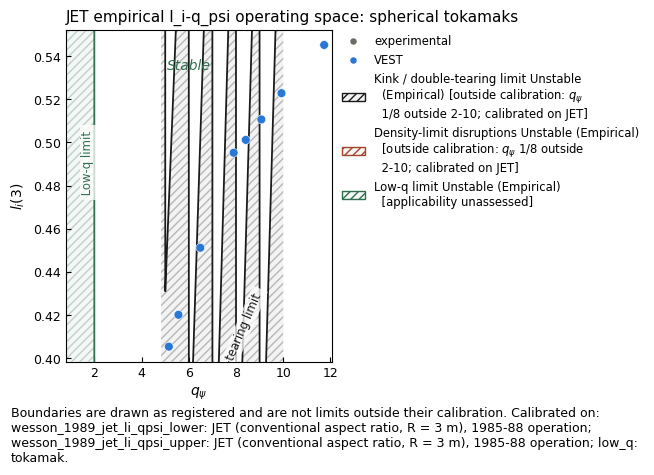

                               drawn      basis      origin                           calibrated on (registry) fixed inputs  \
boundary                                                                                                                      
wesson_1989_jet_li_qpsi_lower   True  empirical  reproduced  JET (conventional aspect ratio, R = 3 m), 1985...            -   
wesson_1989_jet_li_qpsi_upper   True  empirical  reproduced  JET (conventional aspect ratio, R = 3 m), 1985...            -   
low_q                           True  empirical   published                                            tokamak            -   

                              applicability for spherical tokamak  
boundary                                                           
wesson_1989_jet_li_qpsi_lower                             OUTSIDE  
wesson_1989_jet_li_qpsi_upper                             OUTSIDE  
low_q                                                  UNASSESSED  

note: boundary 'wesson_1989_jet_li_qpsi_lower' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_upper' applies to: JET (conventional aspect ratio, R = 3 m), 1985-88 operation
note: boundary 'wesson_1989_jet_li_qpsi_lower' is extrapolated: 1 of 8 value(s) of edge_safety_factor lie outside its fitted range 2..10
note: boundary 'wesson_1989_jet_li_qpsi_upper' is extrapolated: 1 of 8 value(s) of edge_safety_factor lie outside its fitted range 2..10


In [ ]:
if "li_qa_wesson" in SUPPORTED:
    section("li_qa_wesson")
else:
    print("li_qa_wesson is not supported by this table")

### Freidberg $q_*$ against $I_N$

Freidberg's kink safety factor (Eq. 13.160) with its external-kink limit $(1+\kappa)/2$, drawn for each machine at its own elongation.

Kink safety factor against normalized current (qstar_in): x = normalized_current [MA m^-1 T^-1], y = kink_safety_factor_elliptic [-]


machine                                                      VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                        8      1      0   1   1     1    1
excluded                                                        1      0      0   0   0     0    0
missing quantity  kink_safety_factor_elliptic, normalized_current      -      -   -   -     -    -

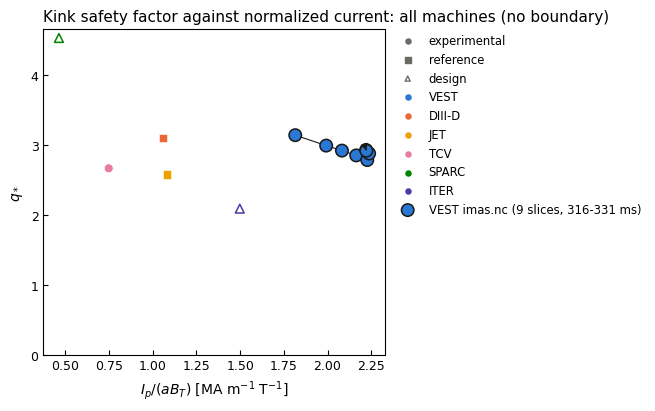

boundaries need ['elongation'] off the axes: one panel per machine, at its own median


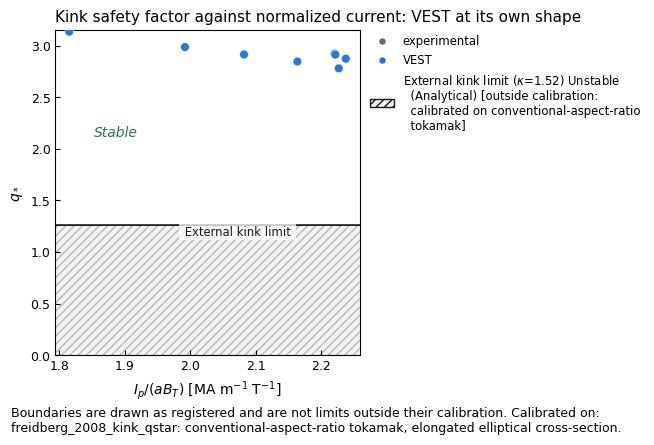

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.52   

                          applicability for spherical tokamak  
boundary                                                       
freidberg_2008_kink_qstar                             OUTSIDE  

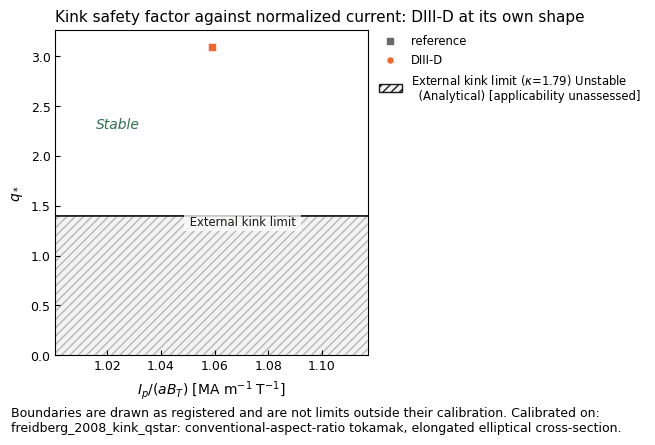

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.79   

                          applicability for conventional tokamak  
boundary                                                          
freidberg_2008_kink_qstar                             UNASSESSED  

MAST-U at its own shape: no state has both coordinates


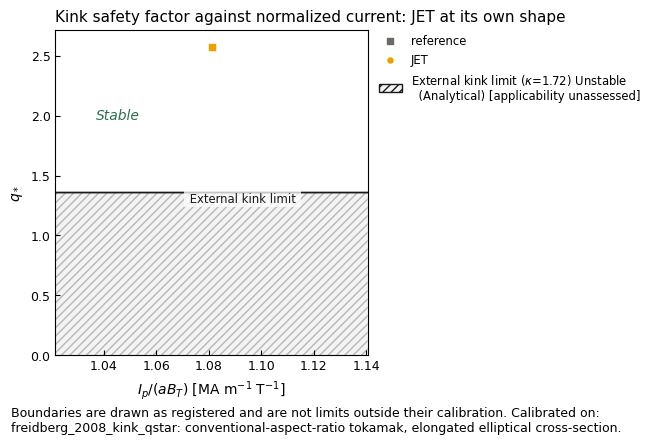

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.72   

                          applicability for conventional tokamak  
boundary                                                          
freidberg_2008_kink_qstar                             UNASSESSED  

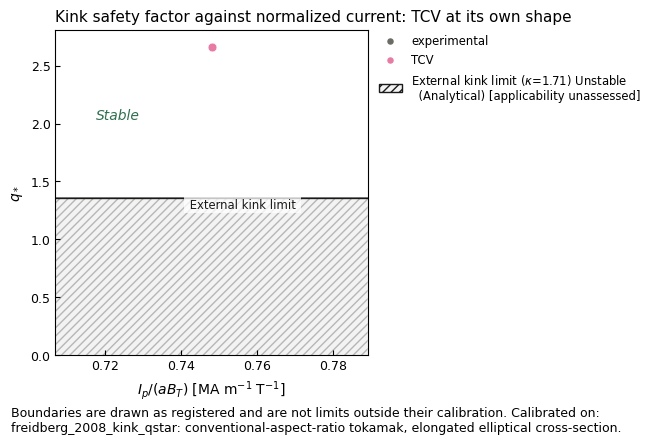

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.71   

                          applicability for conventional tokamak  
boundary                                                          
freidberg_2008_kink_qstar                             UNASSESSED  

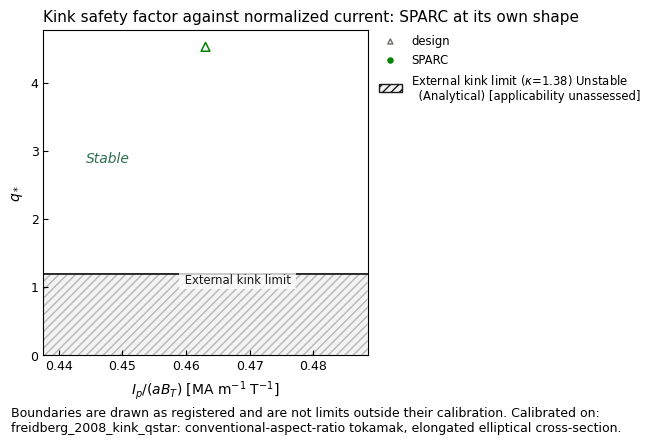

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.38   

                          applicability for conventional tokamak  
boundary                                                          
freidberg_2008_kink_qstar                             UNASSESSED  

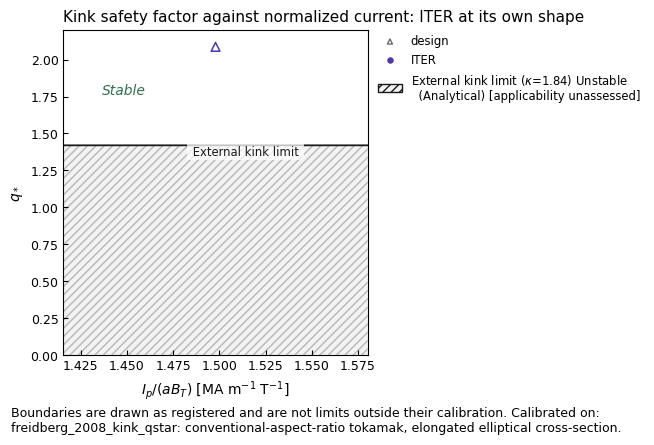

                           drawn               basis     origin                           calibrated on (registry)     fixed inputs  \
boundary                                                                                                                              
freidberg_2008_kink_qstar   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...  elongation=1.84   

                          applicability for conventional tokamak  
boundary                                                          
freidberg_2008_kink_qstar                             UNASSESSED  

note: boundary 'freidberg_2008_kink_qstar' applies to: conventional-aspect-ratio tokamak, elongated elliptical cross-section


In [ ]:
if "qstar_in" in SUPPORTED:
    section("qstar_in")
else:
    print("qstar_in is not supported by this table")

### Menard $q^*$ against $I_N$

Menard's cylindrical safety factor with its $q^* = 1$ limit, from low-aspect-ratio ideal-MHD scans.

Cylindrical safety factor against normalized current (qstar_cyl_in): x = normalized_current [MA m^-1 T^-1], y = kink_safety_factor_cylindrical [-]


machine                                                        VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                          8      1      0   1   1     1    1
excluded                                                          1      0      0   0   0     0    0
missing quantity  kink_safety_factor_cylindrical, normalized_cur...      -      -   -   -     -    -

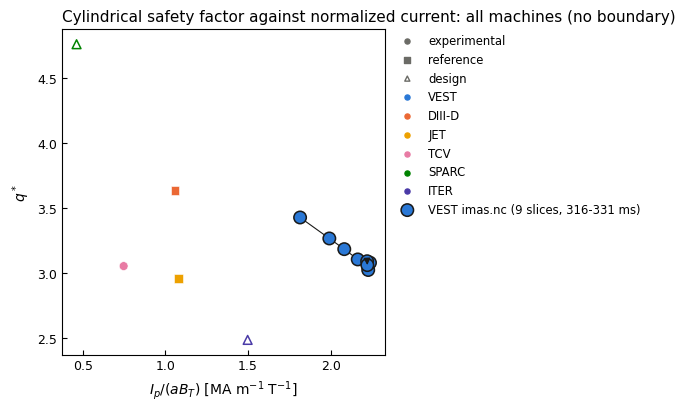

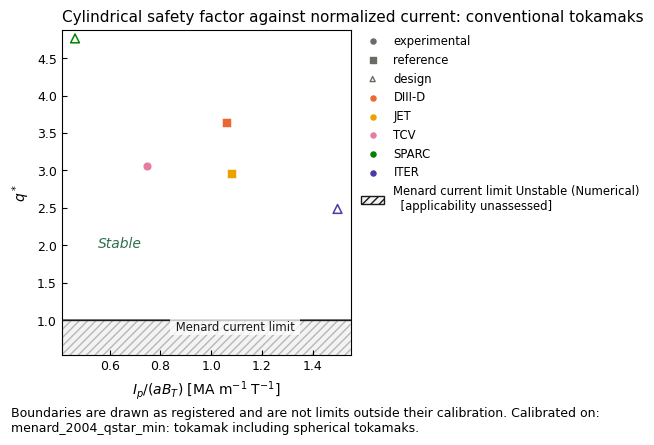

                       drawn                basis     origin              calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                              
menard_2004_qstar_min   True  ideal_mhd_numerical  published  tokamak including spherical tokamaks            -                             UNASSESSED

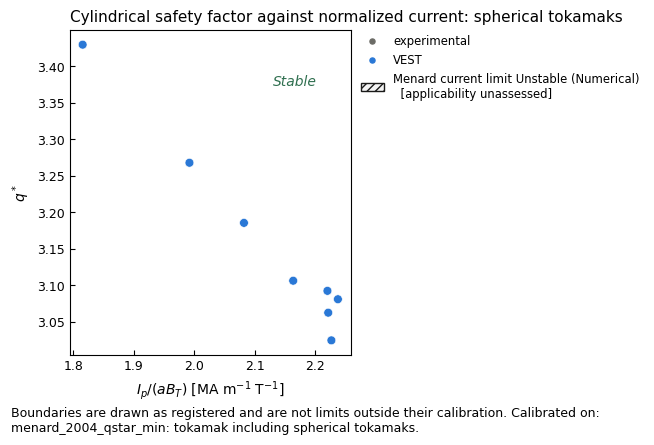

                       drawn                basis     origin              calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                           
menard_2004_qstar_min   True  ideal_mhd_numerical  published  tokamak including spherical tokamaks            -                          UNASSESSED

note: boundary 'menard_2004_qstar_min' applies to: tokamak including spherical tokamaks
note: boundary 'menard_2004_qstar_min' at y = 1 lies outside the plotted range 3..3.45 and is not in view


In [ ]:
if "qstar_cyl_in" in SUPPORTED:
    section("qstar_cyl_in")
else:
    print("qstar_cyl_in is not supported by this table")

### ITER-guideline $q_{95}$ estimate against $I_N$

The $q_{95}$ the ITER design formula assigns to each state's global shape. It is not the equilibrium's $q_{95}$; that is the `q95_li` plane.

ITER-guideline q95 estimate against normalized current (q95_estimate_in): x = normalized_current [MA m^-1 T^-1], y = edge_safety_factor_95_estimate_iter [-]


machine                                                        VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                          8      1      0   1   1     1    1
excluded                                                          1      0      0   0   0     0    0
missing quantity  edge_safety_factor_95_estimate_iter, normalize...      -      -   -   -     -    -

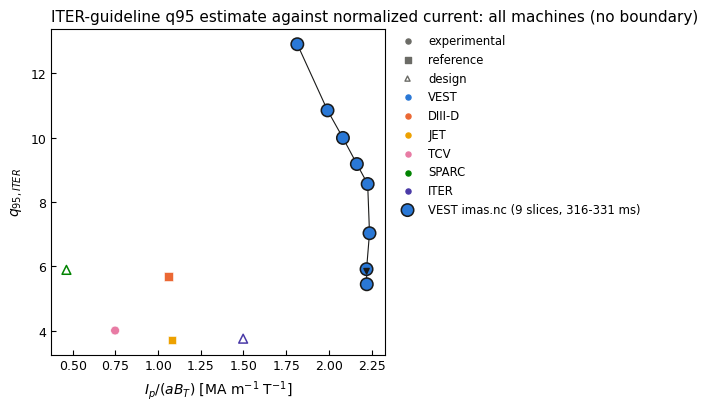

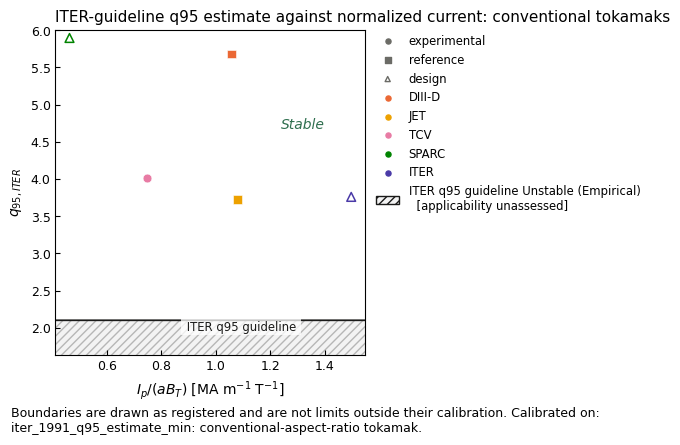

                            drawn      basis     origin           calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                      
iter_1991_q95_estimate_min   True  empirical  published  conventional-aspect-ratio tokamak            -                             UNASSESSED

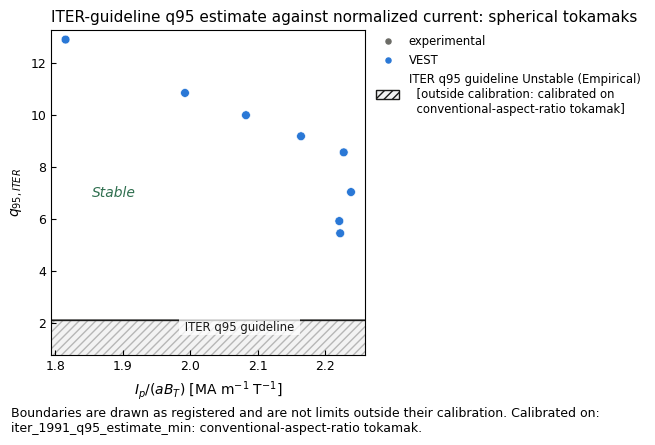

                            drawn      basis     origin           calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                   
iter_1991_q95_estimate_min   True  empirical  published  conventional-aspect-ratio tokamak            -                             OUTSIDE

note: boundary 'iter_1991_q95_estimate_min' applies to: conventional-aspect-ratio tokamak


In [ ]:
if "q95_estimate_in" in SUPPORTED:
    section("q95_estimate_in")
else:
    print("q95_estimate_in is not supported by this table")

### START $q_{95}$ estimate against $I_N$

The START low-aspect-ratio scaling of $q_{95}$ on global shape (limiter, C = 1.0).

START q95 estimate against normalized current (q95_start_estimate_in): x = normalized_current [MA m^-1 T^-1], y = edge_safety_factor_95_estimate_start [-]


machine                                                        VEST DIII-D MAST-U JET TCV SPARC ITER
included                                                          8      1      0   1   1     1    1
excluded                                                          1      0      0   0   0     0    0
missing quantity  edge_safety_factor_95_estimate_start, normaliz...      -      -   -   -     -    -

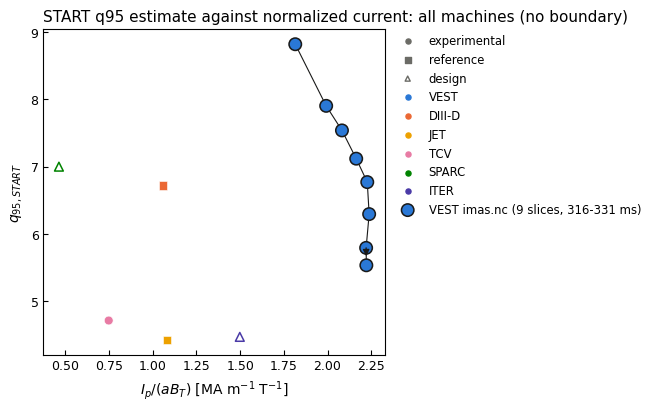

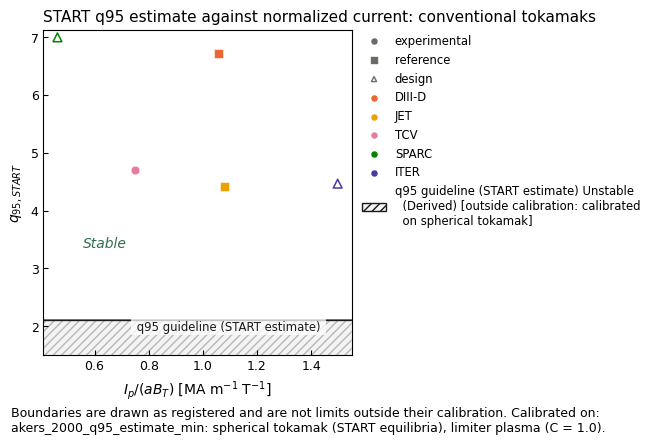

                             drawn      basis   origin                           calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                                     
akers_2000_q95_estimate_min   True  empirical  derived  spherical tokamak (START equilibria), limiter ...            -                                OUTSIDE

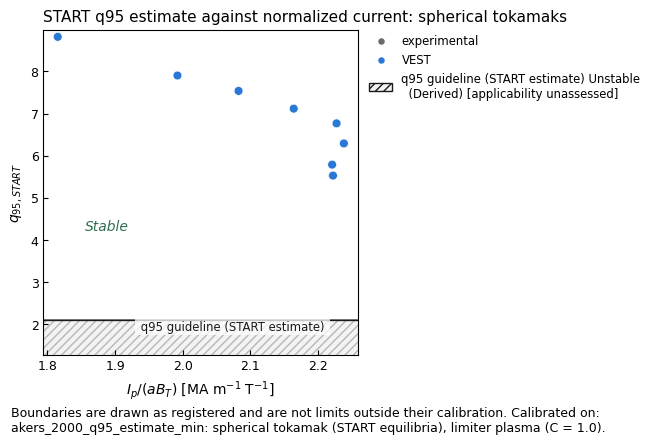

                             drawn      basis   origin                           calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                                  
akers_2000_q95_estimate_min   True  empirical  derived  spherical tokamak (START equilibria), limiter ...            -                          UNASSESSED

note: boundary 'akers_2000_q95_estimate_min' applies to: spherical tokamak (START equilibria), limiter plasma (C = 1.0)


In [ ]:
if "q95_start_estimate_in" in SUPPORTED:
    section("q95_start_estimate_in")
else:
    print("q95_start_estimate_in is not supported by this table")

### $I_p$ against $B_T$

Current limits at fixed shape, drawn for each machine at its own median shape (printed). Across machines the current spans two orders of magnitude, so the all-machine figure is linear and VEST sits at the origin; its own panel shows it.

Plasma current against toroidal field (ip_bt): x = toroidal_field [T], y = plasma_current [MA]


machine                     VEST DIII-D MAST-U JET TCV SPARC ITER
included                       8      1      0   1   1     1    1
excluded                       1      0      0   0   0     0    0
missing quantity  toroidal_field      -      -   -   -     -    -

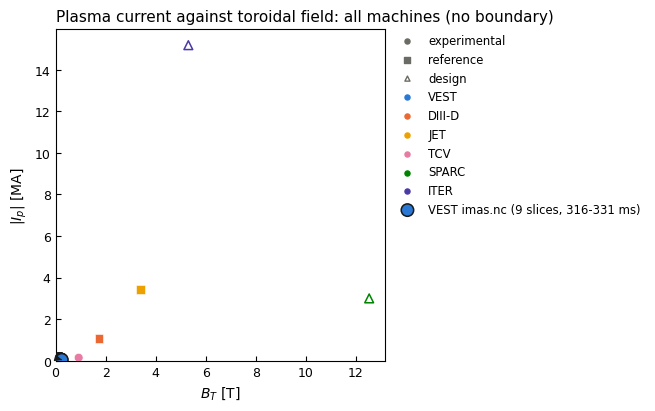

boundaries need ['elongation', 'major_radius', 'minor_radius', 'triangularity'] off the axes: one panel per machine, at its own median


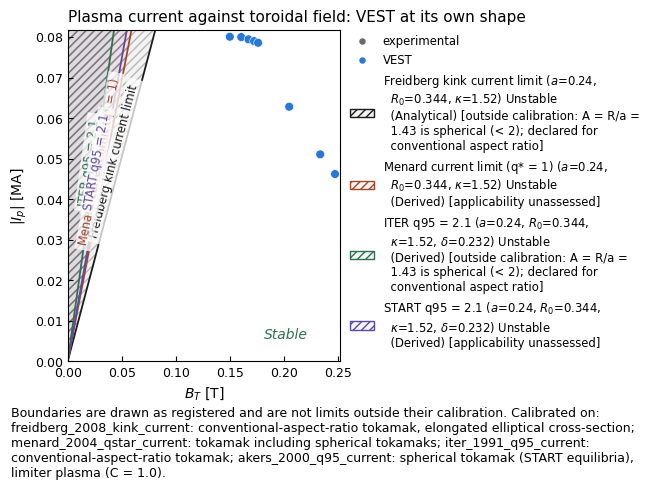

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for spherical tokamak  
boundary                                                                                                            
freidberg_2008_kink_current  minor_radi

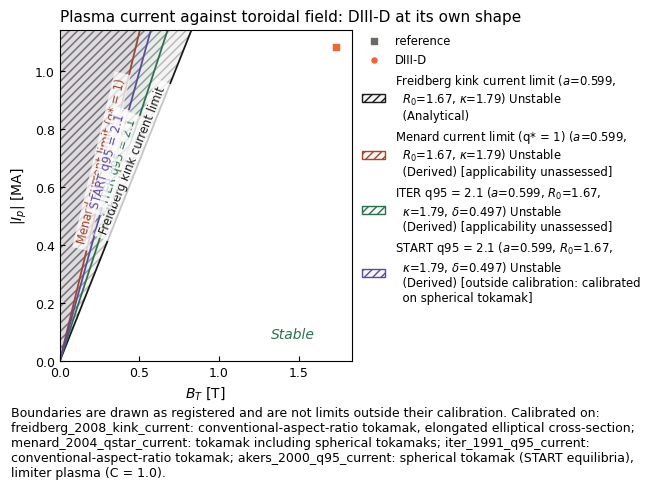

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  mino

MAST-U at its own shape: no state has both coordinates


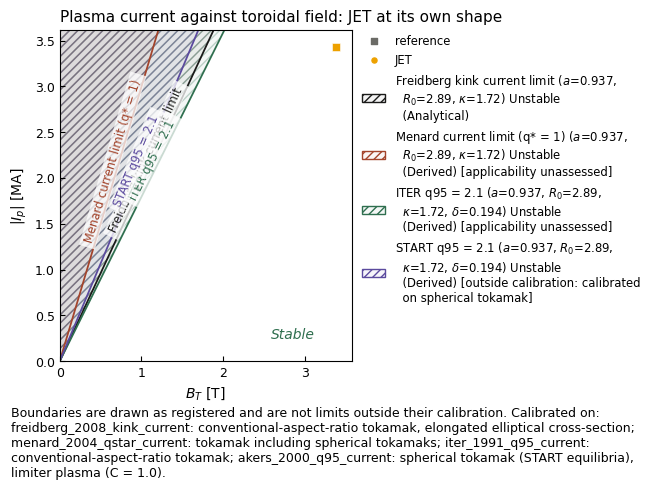

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  mino

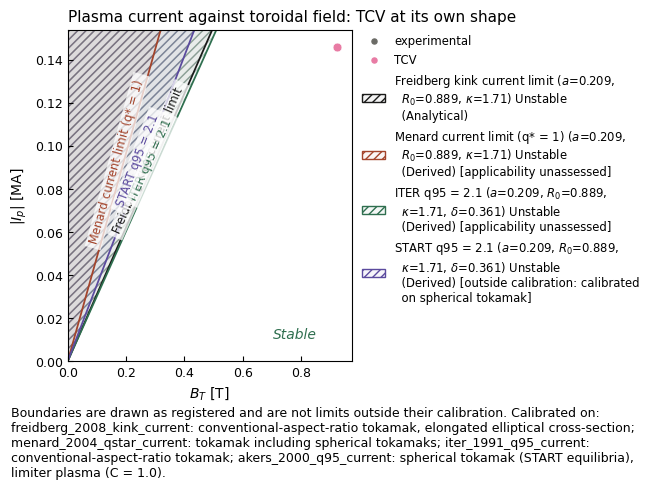

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  mino

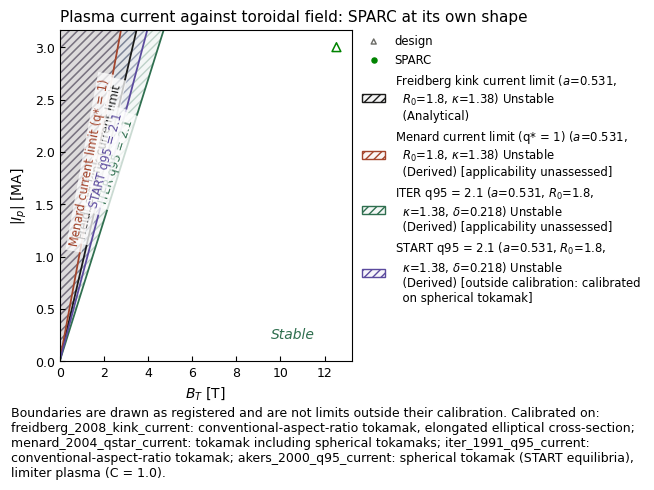

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  mino

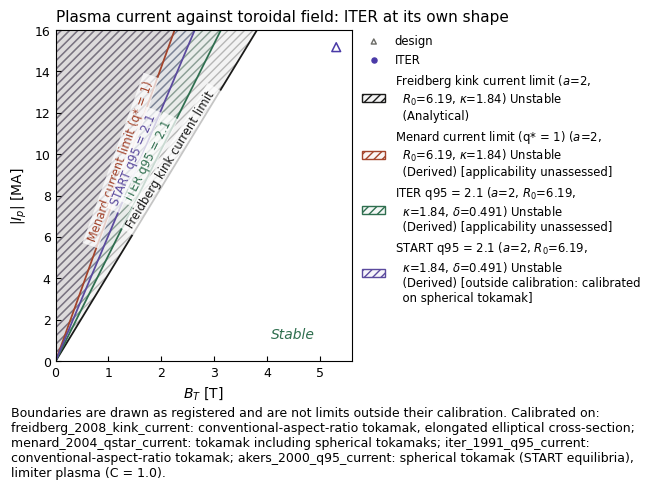

                             drawn                basis     origin                           calibrated on (registry)  \
boundary                                                                                                                
freidberg_2008_kink_current   True   ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   
menard_2004_qstar_current     True  ideal_mhd_numerical    derived               tokamak including spherical tokamaks   
iter_1991_q95_current         True            empirical    derived                  conventional-aspect-ratio tokamak   
akers_2000_q95_current        True            empirical    derived  spherical tokamak (START equilibria), limiter ...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  mino

note: boundary 'freidberg_2008_kink_current' applies to: conventional-aspect-ratio tokamak, elongated elliptical cross-section
note: boundary 'menard_2004_qstar_current' applies to: tokamak including spherical tokamaks
note: boundary 'iter_1991_q95_current' applies to: conventional-aspect-ratio tokamak
note: boundary 'akers_2000_q95_current' applies to: spherical tokamak (START equilibria), limiter plasma (C = 1.0)


In [ ]:
if "ip_bt" in SUPPORTED:
    section("ip_bt")
else:
    print("ip_bt is not supported by this table")

### $I_p$ against $\kappa$

Freidberg's kink current limit (Eq. 13.163), drawn for each machine at its own median $a$, $R_0$ and $B_0$.

Plasma current against elongation (ip_kappa): x = elongation [-], y = plasma_current [MA]


machine                 VEST DIII-D MAST-U JET TCV SPARC ITER
included                   8      1      0   1   1     1    1
excluded                   1      0      0   0   0     0    0
missing quantity  elongation      -      -   -   -     -    -

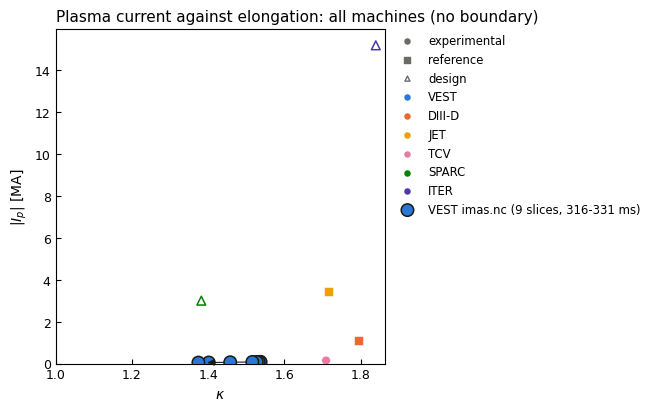

boundaries need ['major_radius', 'minor_radius', 'toroidal_field'] off the axes: one panel per machine, at its own median


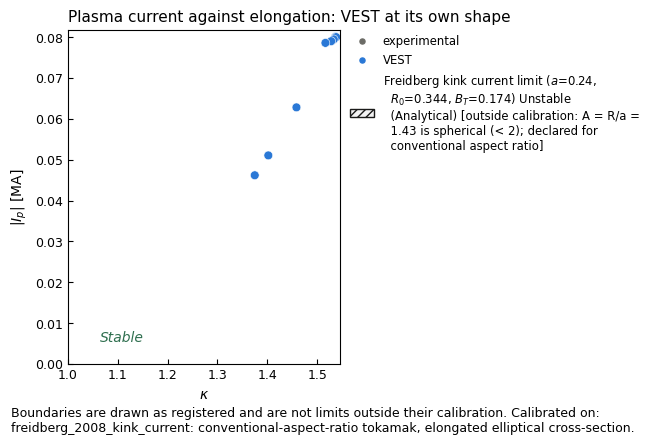

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for spherical tokamak  
boundary                                                                                                            
freidberg_2008_kink_current  minor_radius=0.24, major_radius=0.344, toroida...                             OUTSIDE  

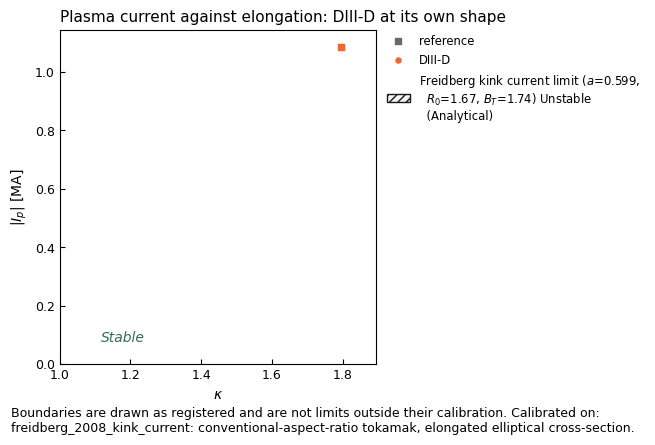

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  minor_radius=0.599, major_radius=1.67, toroida...                              SUPPORTED  

MAST-U at its own shape: no state has both coordinates


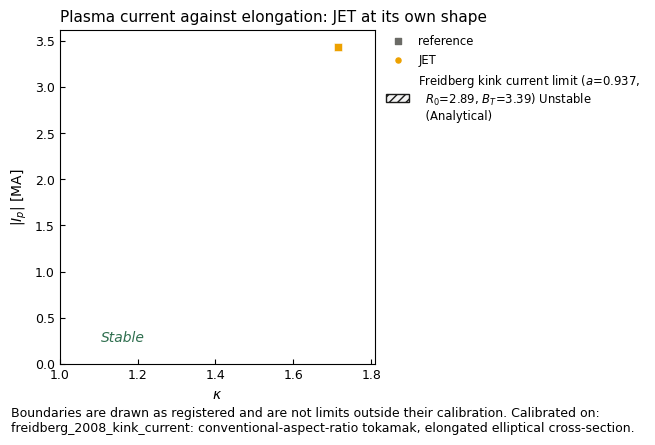

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  minor_radius=0.937, major_radius=2.89, toroida...                              SUPPORTED  

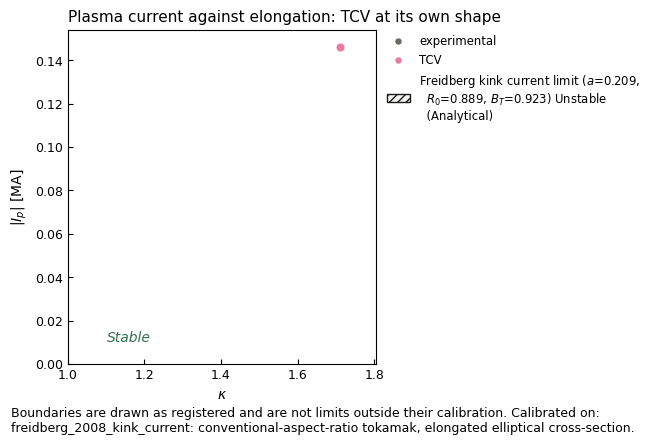

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  minor_radius=0.209, major_radius=0.889, toroid...                              SUPPORTED  

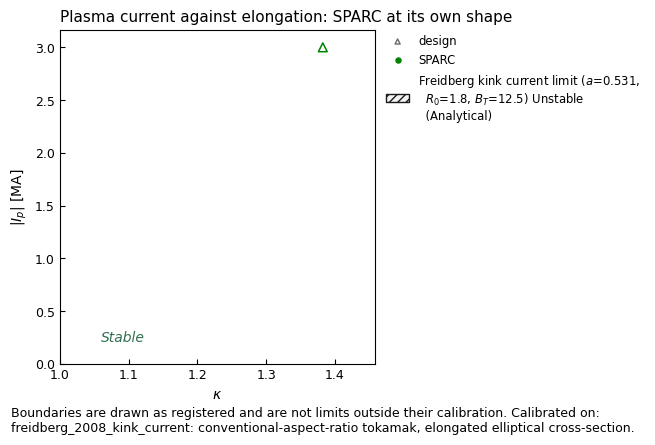

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  minor_radius=0.531, major_radius=1.8, toroidal...                              SUPPORTED  

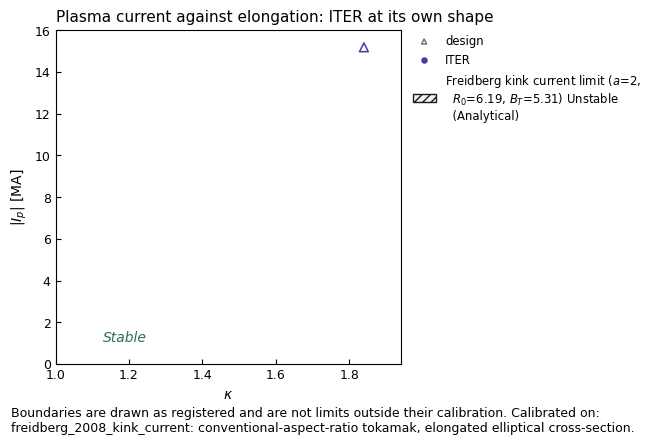

                             drawn               basis     origin                           calibrated on (registry)  \
boundary                                                                                                               
freidberg_2008_kink_current   True  ideal_mhd_analytic  published  conventional-aspect-ratio tokamak, elongated e...   

                                                                  fixed inputs applicability for conventional tokamak  
boundary                                                                                                               
freidberg_2008_kink_current  minor_radius=2, major_radius=6.19, toroidal_fi...                              SUPPORTED  

note: boundary 'freidberg_2008_kink_current' applies to: conventional-aspect-ratio tokamak, elongated elliptical cross-section


In [ ]:
if "ip_kappa" in SUPPORTED:
    section("ip_kappa")
else:
    print("ip_kappa is not supported by this table")

### Supported projections not drawn above

A projection the registry gains later, or one this table newly supports, is drawn here without editing the page.

In [ ]:
DRAWN_ABOVE = {"troyon", "beta_n_li", "q95_li", "li_qa_wesson", "qstar_in", "qstar_cyl_in", "q95_estimate_in",
               "q95_start_estimate_in", "ip_bt", "ip_kappa"}
rest = [key for key in SUPPORTED if key not in DRAWN_ABOVE]
print("supported but not drawn above:", rest or "none")
for key in rest:
    section(key)

supported but not drawn above: none


## 6b. The PR08 population

The public files above are a handful of reference equilibria. The population is the ITPA PR08 profile database
(#1736): every discharge of the public release, read from its 0D file into
`vaft.data.public.pr08_mhd_state_table`, under the same quantity names and units. Its values are the database's own
global quantities, not equilibria reconstructed here, and each carries its provenance:

- `source_direct`: the PR08 variable itself.
- `source_corrected`: a whole-file unit slip of the release, rescaled only while the file is the pinned one. JT-60U
  16107/16168 store IP in MA, and the ITER scenarios and JT-60U 39713 store BETMHD in percent.
- `deterministic_derived`: computed by a registered VAFT function from the row's own values.
- `source_invalid` / `missing`: never drawn.

**QA.** PR08 has no flux map, so the Ampère check of Section 2 cannot run on it. The adapter's own checks take its
place: a value that cannot be the quantity, a unit slip, and T-10's Q95, which is the ITER guideline estimate rather
than an equilibrium $q_{95}$. Every rejection is listed below with its reason.

**One population or two.** A plane combines PR08 with the states of Section 6 only when both tables declare the same
field and radius for both axes (`table.attrs["conventions"]`). PR08 normalises $I_N$ and $\beta_N$ with $B_T$ at the
geometric radius; the equilibrium-state table uses $b_0$ at the reference radius, which on VEST differs by up to
$\times$1.65. Planes with $I_N$ or $\beta_N$ on an axis therefore show PR08 on its own panels.

PR08 has thirteen machines, more than the categorical palette, so its figures colour machines from a 20-colour
palette given to the renderer.

In [ ]:
from vaft.data.public import fetch_pr08_population, mhd_state_coverage, pr08_mhd_state_table, projection_coverage

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    PR08_FILES = fetch_pr08_population()
P = pr08_mhd_state_table(PR08_FILES)
for message in dict.fromkeys(str(w.message) for w in caught if "PR08" in str(w.message)):
    print("download:", message)
print(f"PR08: {len(PR08_FILES)} discharges read, {len(P)} states from {P['machine'].nunique()} machines "
      f"({', '.join(f'{k} {v}' for k, v in P['dataset_type'].value_counts().items())})")
provenance = pd.DataFrame({q: P[f"{q}_provenance"].value_counts() for q in (
    "plasma_current", "toroidal_field", "edge_safety_factor_95", "internal_inductance_li3", "toroidal_beta",
    "normalized_beta", "normalized_current", "elongation")}).fillna(0).astype(int)
display(provenance)
# what was corrected or rejected, and why: each row's notes with its numbers masked, counted per machine
notes = P.loc[P["state_notes"].fillna("") != "", ["machine", "state_notes"]].copy()
notes["notes"] = notes["state_notes"].str.replace(r"[-+]?\d[\d.]*(e[-+]?\d+)?", "#", regex=True)
with pd.option_context("display.max_colwidth", 160):
    display(notes.groupby(["notes", "machine"]).size().rename("states").to_frame())

PR08: 348 discharges read, 422 states from 13 machines (experimental 400, design 22)


                       plasma_current  toroidal_field  edge_safety_factor_95  internal_inductance_li3  toroidal_beta  normalized_beta  normalized_current  \
deterministic_derived               0               0                      0                        0              0              299                 422   
missing                             0               0                      7                      332             21               26                   0   
source_corrected                   31               0                      0                        0              8                0                   0   
source_direct                     391             422                    367                       90            388               97                   0   
source_invalid                      0               0                     48                        0              5                0                   0   

                       elongation  
deterministic_derived

                                                                                                                        states
notes                                                                                                          machine        
BETMHD = # cannot be toroidal_beta                                                                             RTP           5
BETMHD is stored in percent in this file (outside [#, #] on every record); x#                                  ITER          3
                                                                                                               JT-60U        1
BETMHD is stored in percent in this file (outside [#, #] on every record); x#; VOL = # cannot be plasma_volume ITER          4
IP is stored in MA in this file (q# estimate # x the source Q# on every record); x#                            JT-60U       31
KAPPA = # cannot be elongation                                                                                 

In [ ]:
display(mhd_state_coverage(P)[["states", "plasma_current", "toroidal_field", "edge_safety_factor_95",
                                 "internal_inductance_li3", "toroidal_beta", "normalized_beta", "elongation",
                                 "triangularity", "normalized_current"]])
eligible = projection_coverage(P).pivot(index="projection", columns="machine", values="eligible")
eligible.insert(0, "all machines", eligible.sum(axis=1))
display(eligible)

            states  plasma_current  toroidal_field  edge_safety_factor_95  internal_inductance_li3  toroidal_beta  normalized_beta  elongation  triangularity  \
machine                                                                                                                                                         
AUG             11              11              11                     11                        0              0                0          11             11   
C-MOD            5               5               5                      5                        0              5                5           5              5   
DIII-D          55              55              55                     55                        2             55               55          55             55   
FTU              3               3               3                      3                        0              3                3           3              3   
ITER            22              22

machine                   all machines  AUG  C-MOD  DIII-D  FTU  ITER  JET  JT-60U  MAST  RTP  T-10  TEXTOR  TFTR  TORE SUPRA
projection                                                                                                                   
beta_n_li                           90    0      0       2    0    15   39       0     0    0     0       0    34           0
greenwald_fraction_power             0    0      0       0    0     0    0       0     0    0     0       0     0           0
hugill                               0    0      0       0    0     0    0       0     0    0     0       0     0           0
hugill_st                            0    0      0       0    0     0    0       0     0    0     0       0     0           0
ip_bt                              422   11      5      55    3    22   64      48     7    7    48       4   113          35
ip_kappa                           400   11      5      55    3    22   64      48     7    2    48       4    96     

                                             x                                     y          x radius (equilibrium | PR08)  \
beta_n_li              internal_inductance_li3                       normalized_beta                            None | None   
ip_bt                           toroidal_field                        plasma_current            major_radius | major_radius   
ip_kappa                            elongation                        plasma_current                            None | None   
li_qa_wesson                edge_safety_factor               internal_inductance_li3                            None | None   
q95_estimate_in             normalized_current   edge_safety_factor_95_estimate_iter  reference_major_radius | major_radius   
q95_li                   edge_safety_factor_95               internal_inductance_li3                            None | None   
q95_start_estimate_in       normalized_current  edge_safety_factor_95_estimate_start  reference_major_radius | 

Normalized beta against internal inductance (beta_n_li): 90 of 422 PR08 states have both coordinates


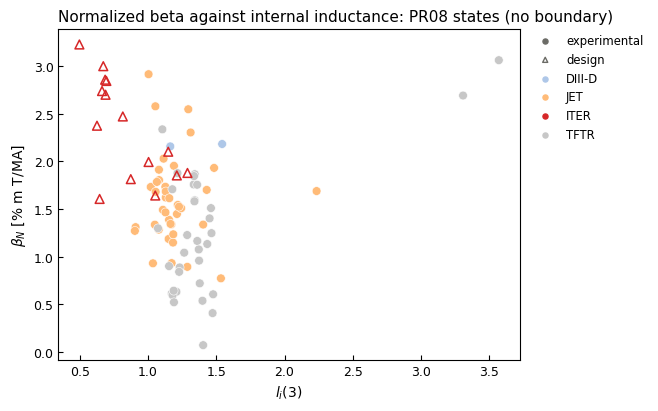

not on one panel with the Section 6 states: an axis uses B_T at another radius


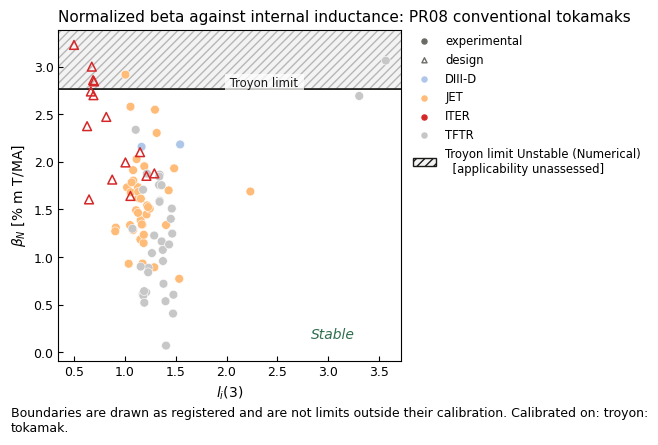

          drawn                basis     origin calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                    
troyon     True  ideal_mhd_numerical  published                  tokamak            -                             UNASSESSED

Plasma current against toroidal field (ip_bt): 422 of 422 PR08 states have both coordinates


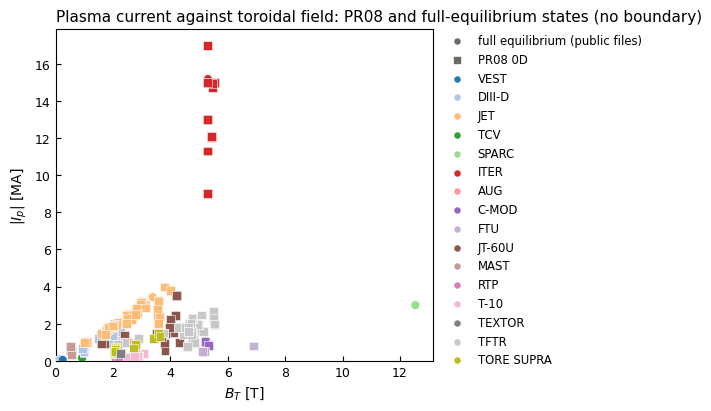

boundaries need ['elongation', 'major_radius', 'minor_radius', 'triangularity'] off the axes; they are drawn per machine for the Section 6 states and not repeated for the thirteen PR08 machines
Plasma current against elongation (ip_kappa): 400 of 422 PR08 states have both coordinates


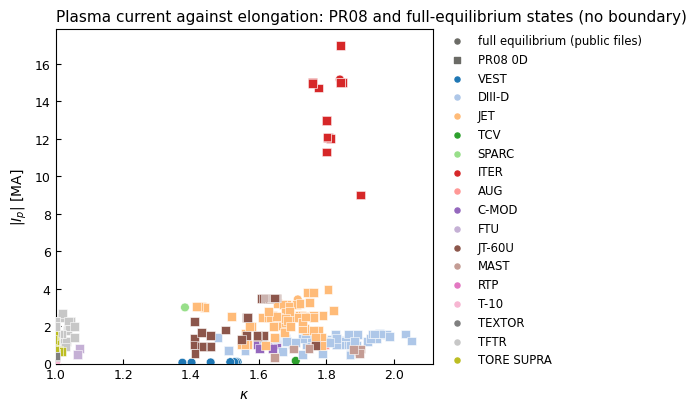

boundaries need ['major_radius', 'minor_radius', 'toroidal_field'] off the axes; they are drawn per machine for the Section 6 states and not repeated for the thirteen PR08 machines
JET empirical l_i-q_psi operating space (li_qa_wesson): PR08 has no ['edge_safety_factor'] (not in the 0D release)
ITER-guideline q95 estimate against normalized current (q95_estimate_in): 399 of 422 PR08 states have both coordinates


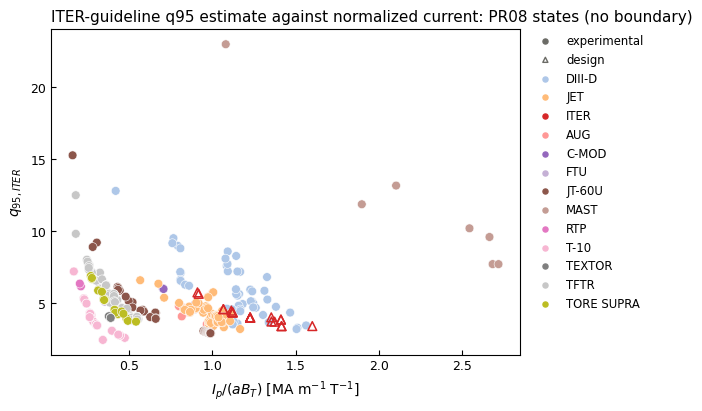

not on one panel with the Section 6 states: an axis uses B_T at another radius


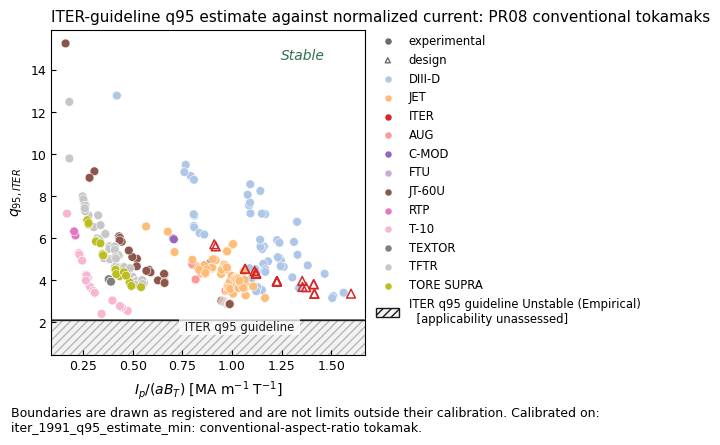

                            drawn      basis     origin           calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                      
iter_1991_q95_estimate_min   True  empirical  published  conventional-aspect-ratio tokamak            -                             UNASSESSED

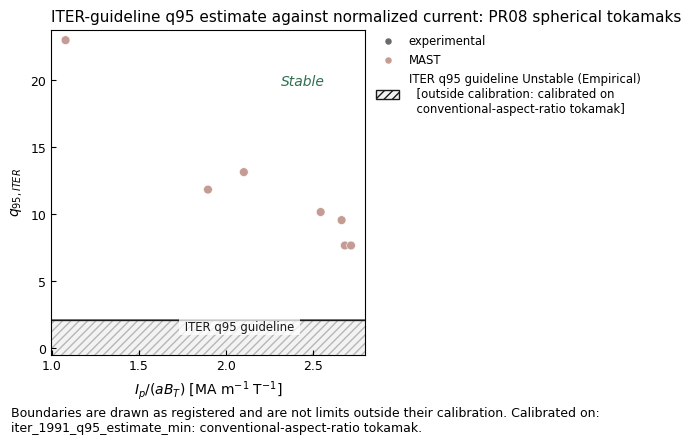

                            drawn      basis     origin           calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                   
iter_1991_q95_estimate_min   True  empirical  published  conventional-aspect-ratio tokamak            -                             OUTSIDE

note: boundary 'iter_1991_q95_estimate_min' applies to: conventional-aspect-ratio tokamak
Internal inductance against q95 (q95_li): 90 of 422 PR08 states have both coordinates


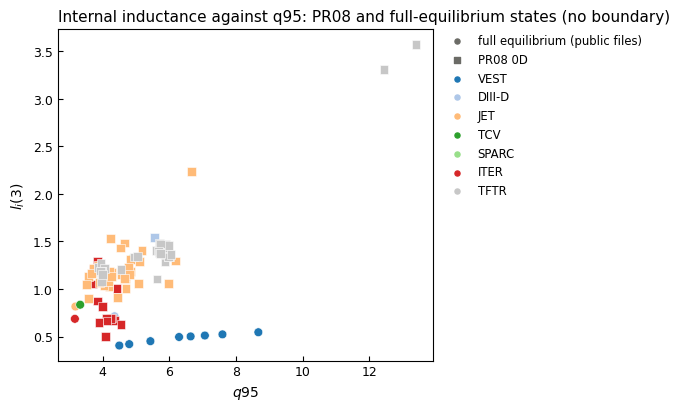

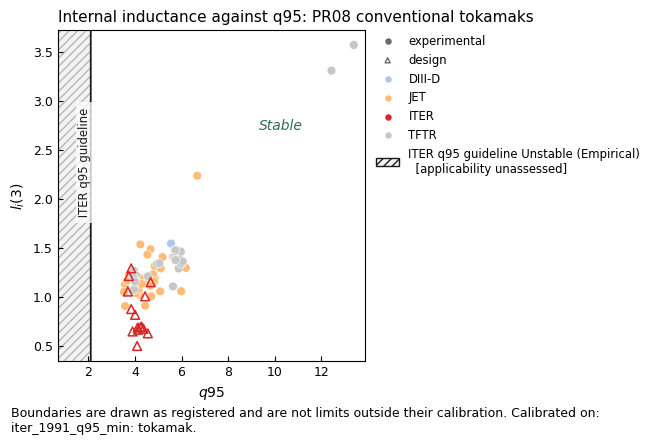

                   drawn      basis     origin calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                   
iter_1991_q95_min   True  empirical  published                  tokamak            -                             UNASSESSED

START q95 estimate against normalized current (q95_start_estimate_in): 176 of 422 PR08 states have both coordinates


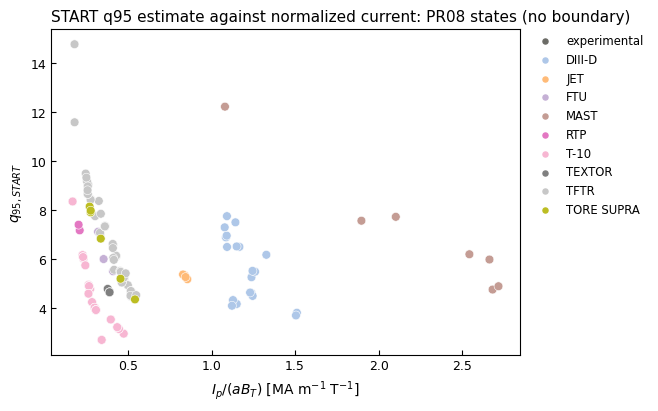

not on one panel with the Section 6 states: an axis uses B_T at another radius


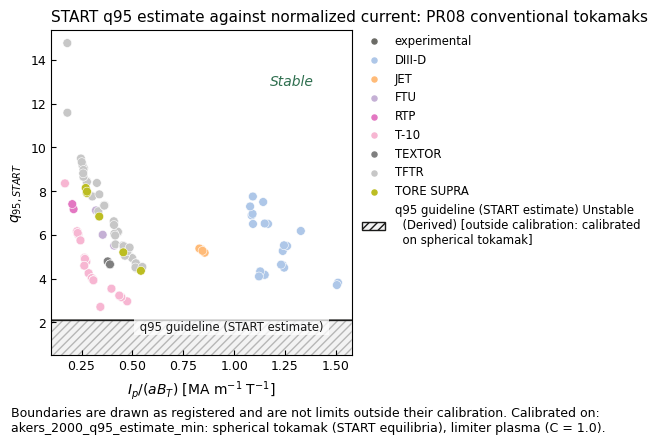

                             drawn      basis   origin                           calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                                     
akers_2000_q95_estimate_min   True  empirical  derived  spherical tokamak (START equilibria), limiter ...            -                                OUTSIDE

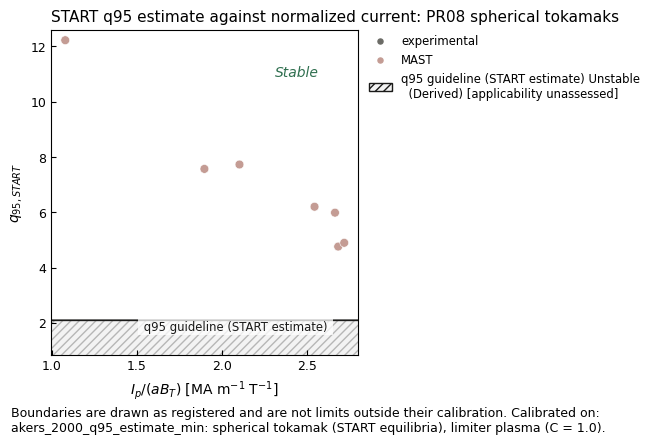

                             drawn      basis   origin                           calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                                  
akers_2000_q95_estimate_min   True  empirical  derived  spherical tokamak (START equilibria), limiter ...            -                          UNASSESSED

note: boundary 'akers_2000_q95_estimate_min' applies to: spherical tokamak (START equilibria), limiter plasma (C = 1.0)
Cylindrical safety factor against normalized current (qstar_cyl_in): 400 of 422 PR08 states have both coordinates


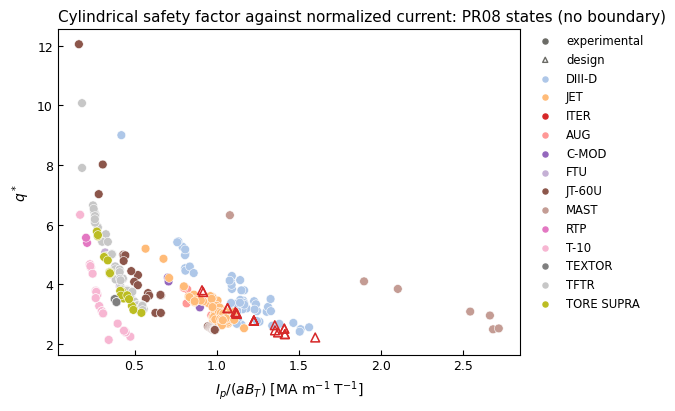

not on one panel with the Section 6 states: an axis uses B_T at another radius


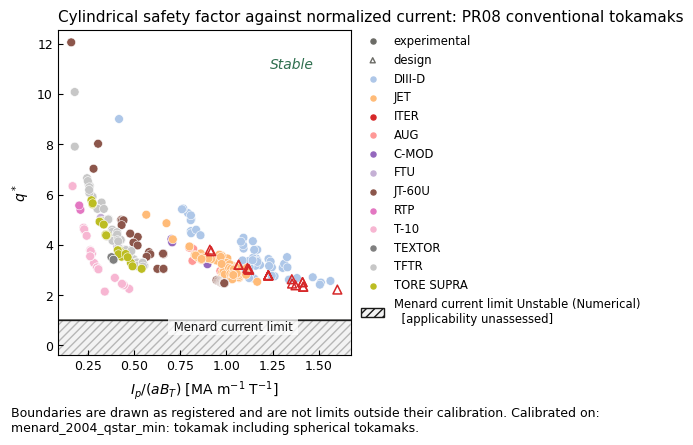

                       drawn                basis     origin              calibrated on (registry) fixed inputs applicability for conventional tokamak
boundary                                                                                                                                              
menard_2004_qstar_min   True  ideal_mhd_numerical  published  tokamak including spherical tokamaks            -                             UNASSESSED

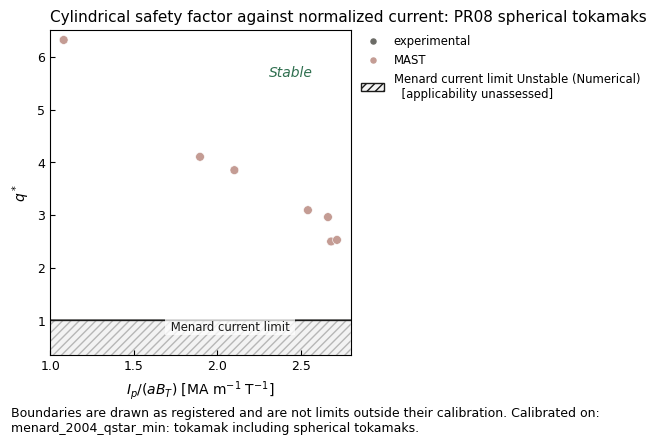

                       drawn                basis     origin              calibrated on (registry) fixed inputs applicability for spherical tokamak
boundary                                                                                                                                           
menard_2004_qstar_min   True  ideal_mhd_numerical  published  tokamak including spherical tokamaks            -                          UNASSESSED

note: boundary 'menard_2004_qstar_min' applies to: tokamak including spherical tokamaks
Kink safety factor against normalized current (qstar_in): 400 of 422 PR08 states have both coordinates


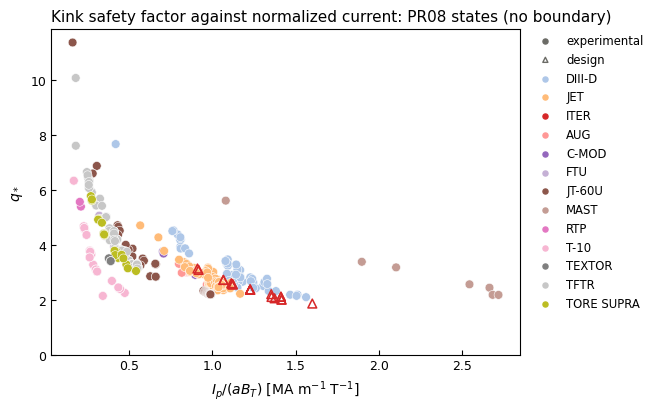

not on one panel with the Section 6 states: an axis uses B_T at another radius
boundaries need ['elongation'] off the axes; they are drawn per machine for the Section 6 states and not repeated for the thirteen PR08 machines
Troyon beta limit (troyon): 396 of 422 PR08 states have both coordinates


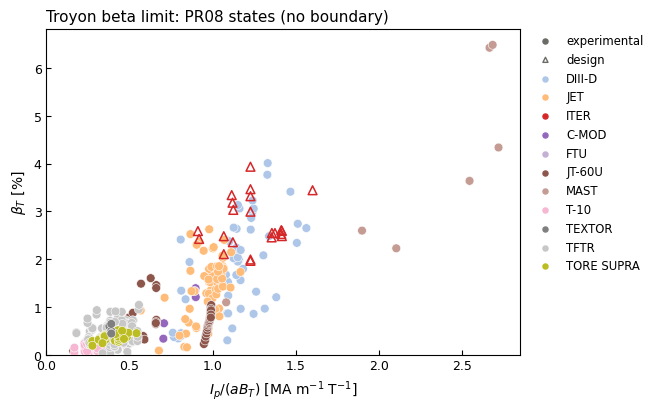

not on one panel with the Section 6 states: an axis uses B_T at another radius


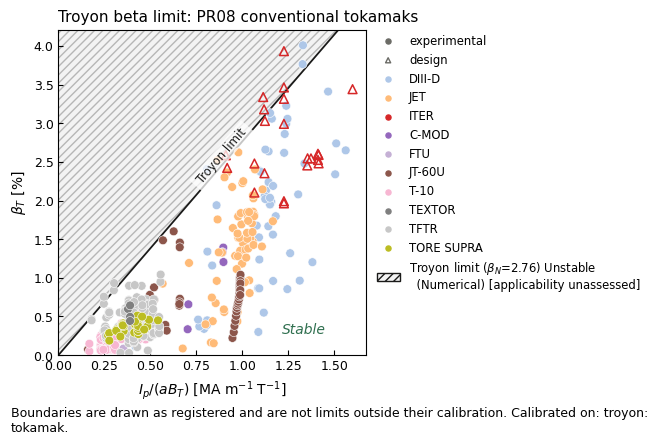

          drawn                basis     origin calibrated on (registry)          fixed inputs applicability for conventional tokamak
boundary                                                                                                                             
troyon     True  ideal_mhd_numerical  published                  tokamak  normalized_beta=2.76                             UNASSESSED

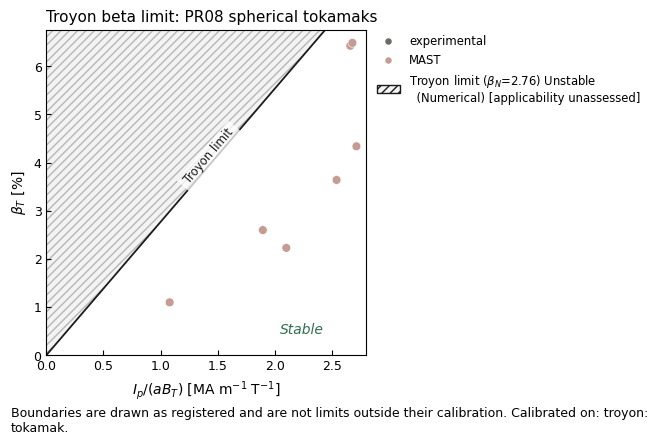

          drawn                basis     origin calibrated on (registry)          fixed inputs applicability for spherical tokamak
boundary                                                                                                                          
troyon     True  ideal_mhd_numerical  published                  tokamak  normalized_beta=2.76                          UNASSESSED

In [ ]:
def _radius(table, column):
    # the radius a field-normalized column is defined with; None for a column no field or radius enters
    convention = table.attrs.get("conventions", {}).get(column)
    return convention["radius_reference"].split()[0] if convention else None


assert T.attrs.get("conventions") and P.attrs.get("conventions"), "both tables must declare their conventions"
SHARED = {}
for key in SUPPORTED:
    p = get_projection(key)
    SHARED[key] = all(_radius(T, q.name) == _radius(P, q.name) for q in (p.x, p.y))
display(pd.DataFrame({key: {"x": get_projection(key).x.name, "y": get_projection(key).y.name,
                            "x radius (equilibrium | PR08)": f"{_radius(T, get_projection(key).x.name)} | "
                                                            f"{_radius(P, get_projection(key).x.name)}",
                            "y radius (equilibrium | PR08)": f"{_radius(T, get_projection(key).y.name)} | "
                                                            f"{_radius(P, get_projection(key).y.name)}",
                            "one population": SHARED[key]} for key in SUPPORTED}).T)

PR08_MACHINES_ORDER = list(dict.fromkeys(MACHINES + sorted(P["machine"].unique())))
_palette = plt.get_cmap("tab20").colors
MACHINE_COLORS = {m: _palette[i % len(_palette)] for i, m in enumerate(PR08_MACHINES_ORDER)}
PR08_FIGURES = {}


def pr08_section(key):
    p = get_projection(key)
    absent = [q.name for q in (p.x, p.y) if q.name not in P.columns]
    if absent:
        print(f"{p.title} ({key}): PR08 has no {absent} (not in the 0D release)")
        return
    rows = P[P[p.x.name].notna() & P[p.y.name].notna()].copy()
    print(f"{p.title} ({key}): {len(rows)} of {len(P)} PR08 states have both coordinates")
    if rows.empty:
        return
    rows["machine"] = pd.Categorical(rows["machine"], categories=PR08_MACHINES_ORDER)
    rows["dataset_type"] = pd.Categorical(rows["dataset_type"], categories=["experimental", "reference", "design"])
    notes = []
    if SHARED[key] and key in FIGURES:
        eq = T[T[p.x.name].notna() & T[p.y.name].notna()].assign(population="full equilibrium (public files)")
        combined = pd.concat([eq, rows.assign(population="PR08 0D")], ignore_index=True)
        combined["machine"] = pd.Categorical(combined["machine"].astype(str), categories=PR08_MACHINES_ORDER)
        combined.attrs = dict(units={**P.attrs["units"], **T.attrs["units"]})
        draw(combined, key, f"{p.title}: PR08 and full-equilibrium states (no boundary)", notes, boundaries=False,
             marker="population", category_colors=MACHINE_COLORS)
    else:
        rows.attrs = dict(P.attrs)
        draw(rows, key, f"{p.title}: PR08 states (no boundary)", notes, boundaries=False,
             category_colors=MACHINE_COLORS)
        if not SHARED[key]:
            print("not on one panel with the Section 6 states: an axis uses B_T at another radius")
    PR08_FIGURES[key] = len(rows)
    off_axis = sorted({name for b in p.default_boundaries for name in getattr(B.get_boundary(b), "input_names", ())
                       if name not in (p.x.name, p.y.name)})
    if off_axis:
        print(f"boundaries need {off_axis} off the axes; they are drawn per machine for the Section 6 states and not "
              "repeated for the thirteen PR08 machines")
    else:
        for machine_class, label in CLASSES:
            sub = rows[rows["machine_class"] == machine_class].copy()
            if sub.empty:
                continue
            sub.attrs = dict(P.attrs, machine_class=machine_class)
            _, ax = draw(sub, key, f"{p.title}: PR08 {label.lower()}", notes, calibration=True,
                         boundaries="default", category_colors=MACHINE_COLORS)
            report = boundary_table(ax, machine_class.replace("_", " "))
            if report is not None:
                display(report)
    for message in dict.fromkeys(notes):
        print("note:", message)


for key in SUPPORTED:
    pr08_section(key)

### VEST Tier A

The conference atlas's VEST population (the #1331 Tier A campaign) is not public and not packaged. When
`VAFT_ATLAS_DIR` points at a copy of the atlas tables it can join these planes; loading it here is the follow-up of
#1620. This page reports whether it is present.

In [ ]:
atlas_dir = os.environ.get("VAFT_ATLAS_DIR")
base_table = Path(atlas_dir).expanduser() / "lane_v" / "efit_base.csv" if atlas_dir else None
print("VEST Tier A atlas:", f"present at {base_table}" if base_table is not None and base_table.is_file()
      else "not available here (set VAFT_ATLAS_DIR to the atlas directory)")

VEST Tier A atlas: not available here (set VAFT_ATLAS_DIR to the atlas directory)


## 7. Spherical and conventional tokamaks: the geometry is kept

The planes above do not erase geometry: $\epsilon$, $\kappa$ and $\delta$ stay in every row, and the spherical and
conventional populations never share a boundary panel. The geometry each machine's states actually have is
listed here, beside the class declared in Section 1.

In [ ]:
geometry = ["aspect_ratio", "inverse_aspect_ratio", "elongation", "area_elongation", "triangularity",
            "normalized_shafranov_shift"]
summary = T.groupby(["machine_class", "machine"], observed=True)[geometry].agg(["min", "median", "max"])
display(summary.round(3))

                             aspect_ratio               inverse_aspect_ratio               elongation               area_elongation                \
                                      min median    max                  min median    max        min median    max             min median    max   
machine_class        machine                                                                                                                        
conventional_tokamak DIII-D         2.784  2.784  2.784                0.359  0.359  0.359      1.794  1.794  1.794           1.660  1.660  1.660   
                     JET            3.084  3.084  3.084                0.324  0.324  0.324      1.716  1.716  1.716           1.582  1.582  1.582   
                     TCV            4.248  4.248  4.248                0.235  0.235  0.235      1.710  1.710  1.710           1.612  1.612  1.612   
                     SPARC          3.390  3.390  3.390                0.295  0.295  0.295      1.382  1.3

## 8. What is not supported, and why

Every registered projection is either drawn above or listed here with its reason. Section 2 lists the rows that
are not states.

In [ ]:
display(pd.DataFrame(unsupported)[["projection", "reason"]])
print(f"drawn: {sorted(FIGURES)}")
print(f"unsupported: {[u['projection'] for u in unsupported]}")
assert sorted(set(FIGURES) | {u["projection"] for u in unsupported}) == sorted(list_projections())

                 projection                                             reason
0  greenwald_fraction_power  loss_power is not an equilibrium-state column ...
1                    hugill  murakami_parameter is not an equilibrium-state...
2                 hugill_st  murakami_parameter is not an equilibrium-state...
3              lh_threshold  line_average_density is not an equilibrium-sta...
4               li_qa_cheng  cylinder_edge_safety_factor is not an equilibr...
5           rho_star_beta_n  rho_star_verdoolaege_2021 is not an equilibriu...
6          rho_star_nu_star  rho_star_verdoolaege_2021 is not an equilibriu...
7   rho_star_omega_ci_tau_e  rho_star_verdoolaege_2021 is not an equilibriu...

drawn: ['beta_n_li', 'ip_bt', 'ip_kappa', 'li_qa_wesson', 'q95_estimate_in', 'q95_li', 'q95_start_estimate_in', 'qstar_cyl_in', 'qstar_in', 'troyon']
unsupported: ['greenwald_fraction_power', 'hugill', 'hugill_st', 'lh_threshold', 'li_qa_cheng', 'rho_star_beta_n', 'rho_star_nu_star', 'rho_star_omega_ci_tau_e']


## 9. VEST against the VEST atlas

The conference atlas builds its table with `workflow/operational_space_atlas/build_efit_base.py` and derives the
remaining columns in its own Data cell. This section runs that script's row builder on the same VEST slices and
applies the atlas cell's derivation to it. Then it checks two things for every supported projection:

1. the x and y values agree with this page's;
2. the overlay plan, meaning which registered boundaries are drawn, their sampled curves and their fixed inputs,
   is identical.

The atlas plots the #1331 Tier A campaign, which is not packaged. This page uses the packaged sample shot 39915,
so the **populations** differ by design. The derivations, the units and the boundaries do not.

In [ ]:
spec = importlib.util.spec_from_file_location(
    "build_efit_base", Path("..") / "workflow" / "operational_space_atlas" / "build_efit_base.py")
atlas_base = importlib.util.module_from_spec(spec)
spec.loader.exec_module(atlas_base)

vest_ods = next(ods for ods, prov in entries if prov["machine"] == "VEST")
mine = T[T["machine"] == "VEST"].sort_values(TIME).reset_index(drop=True)
mine.attrs = dict(T.attrs)
logging.disable(logging.WARNING)   # the #325 reference-radius message was printed in Section 2


def atlas_row(t):
    # build_efit_base.main records a raising slice as "failed"; so does this
    try:
        return atlas_base._row(vest_ods, t)
    except Exception as error:
        return {"base_status": "failed", "base_reason": f"{type(error).__name__}: {error}"}


try:
    atlas = pd.DataFrame([atlas_row(t) for t in mine[TIME]])
finally:
    logging.disable(logging.NOTSET)
accepted = (atlas["base_status"] == "valid").to_numpy()
for t, reason in zip(mine.loc[~accepted, TIME], atlas.loc[~accepted, "base_reason"]):
    print(f"t = {t:.4f} s: the atlas builder rejects this slice ({reason[:90]}); this page keeps it with missing "
          "coordinates, so it is not compared")
atlas, mine = atlas[accepted].reset_index(drop=True), mine[accepted].reset_index(drop=True)
mine.attrs = dict(T.attrs)
# the atlas notebook's Data cell, on its own column names
atlas["plasma_current"] = atlas["plasma_current_ma"]
atlas["minor_radius"] = atlas["minor_radius_m"]
atlas["major_radius"] = atlas["major_radius_geo_m"]
atlas["toroidal_field"] = atlas["b0_t"] * atlas["r_reference_m"] / atlas["major_radius_geo_m"]
atlas["aspect_ratio"] = atlas["major_radius"] / atlas["minor_radius"]
atlas["kink_safety_factor_elliptic"] = B.kink_coordinates(atlas["minor_radius"], atlas["major_radius"],
                                                          atlas["toroidal_field"], atlas["elongation"],
                                                          atlas["plasma_current"])
atlas.attrs["units"] = dict(atlas_base.UNITS, plasma_current="MA", minor_radius="m", major_radius="m",
                            toroidal_field="T", aspect_ratio="-")

rows = []
for key in SUPPORTED:
    p = get_projection(key)
    if p.x.name not in atlas or p.y.name not in atlas:
        rows.append({"projection": key, "compared": "no: the atlas table has no such column",
                     "max |relative difference|": np.nan, "same overlay": None})
        continue
    pairs = [(atlas[c].to_numpy(float), mine[c].to_numpy(float)) for c in (p.x.name, p.y.name)]
    if any((np.isnan(u) != np.isnan(v)).any() for u, v in pairs):
        diff = np.inf   # a value on one side only is a disagreement, not a NaN to skip
    else:
        diff = max(float(np.nanmax(np.abs(u / v - 1.0))) for u, v in pairs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        span = dict(x_range=(0.0, float(mine[p.x.name].max()) * 1.2), y_range=(0.0, float(mine[p.y.name].max()) * 1.2))
        a, b = population_overlay(atlas, key, **span), population_overlay(mine, key, **span)
    same = (a.keys == b.keys and a.omitted == b.omitted
            and all(np.allclose(ca.x, cb.x, equal_nan=True) and np.allclose(ca.y, cb.y, equal_nan=True)
                    and ca.fixed.keys() == cb.fixed.keys()
                    and all(np.isclose(ca.fixed[k], cb.fixed[k]) for k in ca.fixed)
                    for ca, cb in zip(a.curves, b.curves)))
    rows.append({"projection": key, "compared": f"{len(mine)} VEST slices", "max |relative difference|": diff,
                 "same overlay": same})
REGRESSION = pd.DataFrame(rows).set_index("projection")
display(REGRESSION)

t = 0.3310 s: the atlas builder rejects this slice (ValueError: `equilibrium.time_slice.8.boundary.outline.r` has no data); this page keeps it with missing coordinates, so it is not compared


~/miniforge3/envs/imas/lib/python3.12/site-packages/omas/omas_physics.py:2855: RuntimeWarning: invalid value encountered in scalar divide
~/miniforge3/envs/imas/lib/python3.12/site-packages/omas/omas_physics.py:2856: RuntimeWarning: invalid value encountered in scalar divide


                                                     compared  max |relative difference| same overlay
projection                                                                                           
beta_n_li                                       8 VEST slices                        0.0         True
ip_bt                                           8 VEST slices                        0.0         True
ip_kappa                                        8 VEST slices                        0.0         True
li_qa_wesson                                    8 VEST slices                        0.0         True
q95_estimate_in        no: the atlas table has no such column                        NaN         None
q95_li                                          8 VEST slices                        0.0         True
q95_start_estimate_in  no: the atlas table has no such column                        NaN         None
qstar_cyl_in           no: the atlas table has no such column                     

Three $I_N$-plane coordinates (Menard's $q^*$, the ITER and START $q_{95}$ estimates) are not columns of the
atlas table. The atlas computes them only in its proxy comparison, so they are not compared here. The `qstar_in`
comparison checks the inputs, not the formula: both sides evaluate Freidberg's $q_*$ with the same registry
function. Every projection the atlas table carries agrees to rounding, with matching NaN masks, and draws the same
boundaries at the same inputs.

## 10. Summary and validation

In [ ]:
checks = {
    "every projection is drawn or listed as unsupported":
        sorted(set(FIGURES) | {u["projection"] for u in unsupported}) == sorted(list_projections()),
    "every plotted axis column has its unit declared and equal to the axis unit":
        all(T.attrs["units"].get(q.name) == q.unit for k in FIGURES for q in (get_projection(k).x, get_projection(k).y)),
    "every row is a state or carries its reason":
        bool((STATES["state_status"].eq("valid") | STATES["state_reason"].fillna("").ne("")).all()),
    "every state is in COCOS 11": bool((T["cocos_target"] == 11).all()),
    "VEST matches the atlas derivation (relative difference < 1e-9)":
        bool((REGRESSION["max |relative difference|"].dropna() < 1e-9).all()),
    "VEST draws the atlas's boundaries": bool(REGRESSION["same overlay"].dropna().astype(bool).all()),
    "every PR08 axis column drawn has the axis unit":
        all(P.attrs["units"].get(q.name) == q.unit for k in PR08_FIGURES
            for q in (get_projection(k).x, get_projection(k).y)),
    "every PR08 state has a unique record_id": bool(P["record_id"].is_unique),
    "no rejected or missing PR08 value is drawn":
        all(P.loc[P[q.name].notna(), f"{q.name}_provenance"].isin(
            ["source_direct", "source_corrected", "deterministic_derived"]).all()
            for k in PR08_FIGURES for q in (get_projection(k).x, get_projection(k).y)),
    "PR08 shares a panel only where both tables declare the same radius":
        all(SHARED[k] == all(_radius(T, q.name) == _radius(P, q.name)
                             for q in (get_projection(k).x, get_projection(k).y)) for k in PR08_FIGURES),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), [k for k, v in checks.items() if not v]
print(f"{len(T)} states from {T['machine'].nunique()} machines on {len(FIGURES)} projections; "
      f"{len(unsupported)} projections unsupported; {len(not_states)} rows not states")
print(f"PR08: {len(P)} states from {P['machine'].nunique()} machines on {len(PR08_FIGURES)} projections")

                                                    passed
every projection is drawn or listed as unsupported    True
every plotted axis column has its unit declared...    True
every row is a state or carries its reason            True
every state is in COCOS 11                            True
VEST matches the atlas derivation (relative dif...    True
VEST draws the atlas's boundaries                     True
every PR08 axis column drawn has the axis unit        True
every PR08 state has a unique record_id               True
no rejected or missing PR08 value is drawn            True
PR08 shares a panel only where both tables decl...    True

14 states from 6 machines on 10 projections; 8 projections unsupported; 1 rows not states
PR08: 422 states from 13 machines on 9 projections


## Follow-up

- Most boundaries are UNASSESSED for every population here: their registry entries declare no calibration range
  that covers these machines. Declaring those ranges belongs to the registry (#1628), not to this page.
- #1603 refines the Wesson and Cheng–Furth–Boozer $l_i$–$q$ family and the mapping onto the cylinder plane.
- Density and power planes (Hugill, Greenwald fraction, L–H threshold) and the ρ* planes need a database that
  supplies them.
- The VEST Tier A population of the conference atlas, from `VAFT_ATLAS_DIR`, on the same planes.
- One field convention for $I_N$ and $\beta_N$ across the equilibrium-state and PR08 tables, so the Troyon and $I_N$
  planes can hold both populations.